<a id='I'></a>
# MCDI503 — Exploración Inteligente para la Ciencia de Datos
## Proyecto Final — Fase 4: Pipeline exploratorio, ingeniería y selección de variables
### I. Encabezado e identificación del notebook

| Campo | Detalle |
|---|---|
| **Curso** | MCDI503 — Exploración Inteligente para la Ciencia de Datos |
| **Evaluación** | Sumativa 3 — Fase 4 (cierre del proyecto) |
| **Integrantes** | Marcelo Corro · Carolina Cortés · Pedro Espinoza · Juan Valdebenito |
| **Dataset** | Titanic (`seaborn` · 891 obs × 15 variables) + tabla auxiliar de puertos (repositorio del proyecto) |
| **Docente** | Sergio Paraíso |
| **Fecha** | Octubre 2026 |
| **Repositorio** | https://github.com/k1ngdom0fbullsh1t/proyecto-grupo4-mcdi503 |

**Problema del proyecto:** identificar qué factores se asocian a la supervivencia de los pasajeros del Titanic.

**Propósito del notebook:** construir un **pipeline exploratorio reproducible** que, a partir de los hallazgos del análisis exploratorio de las fases anteriores, (1) transforme y normalice las variables relevantes, (2) cree variables derivadas con sentido en el contexto del problema y (3) seleccione de forma preliminar las características más pertinentes para una etapa posterior de modelamiento, documentando cada decisión y su efecto sobre los datos.

**Pertinencia del dataset:** se continúa con Titanic, el dataset trabajado en las fases previas y recomendado por la asignatura. Combina variables numéricas asimétricas (`fare`), variables con faltantes informativos (`age`, `deck`), variables categóricas nominales y ordinales (`sex`, `embarked`, `pclass`) y relaciones no lineales e interacciones (`family_size`, `sex` × `pclass`), lo que permite aplicar todas las técnicas de ingeniería y selección de variables de esta fase.

**Alcance:** el trabajo es exploratorio y de preparación. No se entrenan modelos predictivos; el resultado es un dataset preparado y un pipeline listo para la etapa de modelamiento.

**Valor para la toma de decisiones:** el pipeline convierte los hallazgos descriptivos (quiénes sobrevivieron y por qué) en un conjunto reducido, interpretable y trazable de variables, que permite priorizar los factores con mayor peso explicativo y servir de base a un modelo de clasificación de la supervivencia.

**Independencia del notebook:** este notebook es autocontenido. Parte de las fuentes originales y vuelve a aplicar, mediante una función documentada, las decisiones de limpieza e integración de las Fases 2 y 3 (Sumativa 2), sin depender de archivos generados por notebooks anteriores.

**Mapa del pipeline**

```
Fuentes originales ──► II. Carga ──► III. preparar_base() ──► IV. Transformaciones ──► V. Variables derivadas
 (seaborn + CSV web)                  (limpieza F2-F3)          (log, z-score, codificación)   (interacciones, flags)
                                                                                                    │
            IX. Cierre ◄── VIII. Dataset final ◄── VII. Pipeline sklearn + registro ◄── VI. Selección preliminar
                            (df_modelo)             (log_decisiones)                    (criterios C1–C5)
```

**Índice**

- [I. Encabezado e identificación](#I)
- [II. Carga de datos y preparación del entorno](#II)
- [III. Revisión inicial del dataset](#III)
- [IV. Transformaciones y normalizaciones aplicadas](#IV)
- [V. Variables derivadas o creadas](#V)
- [VI. Selección preliminar de características](#VI)
- [VII. Documentación y trazabilidad del pipeline](#VII)
- [VIII. Resultado final del dataset preparado](#VIII)
- [IX. Supuestos, limitaciones y cierre del notebook](#IX)
- [X. Bibliografía](#X)

**Convenciones de nombres:** `_log` = transformación logarítmica · `_z` = estandarizada (media 0, desviación 1) · `_ord` = codificación ordinal · `_cat` = recodificación en categorías · `emb_*`, `fam_*`, `sc_*` = variables *one-hot* · variables 0/1 = indicadores (*flags*). Cada decisión se registra con la función `registrar()` y se consolida en la Sección VII.

<a id='II'></a>
## II. Carga de datos y preparación del entorno

Se importan las librerías, se fijan la semilla y los parámetros gráficos, y se cargan las dos fuentes de trabajo: el dataset Titanic desde `seaborn` y la tabla auxiliar de puertos desde el repositorio del proyecto (misma fuente web utilizada en la Sumativa 2).

In [1]:
import warnings
# Se silencian solo avisos de deprecación de librerías (no afectan los resultados)
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from scipy import stats
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# ── Parámetros globales ──────────────────────────────────────────────────
SEMILLA = 42
np.random.seed(SEMILLA)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (9, 4),
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11})
PALETTE = {'No sobrevivió': '#e74c3c', 'Sobrevivió': '#2ecc71'}
URL_PUERTOS = ('https://raw.githubusercontent.com/k1ngdom0fbullsh1t/'
               'proyecto-grupo4-mcdi503/main/data/external/puertos_embarque.csv')

print(f'Versiones -> pandas {pd.__version__} | numpy {np.__version__} | '
      f'seaborn {sns.__version__} | scikit-learn {sklearn.__version__}')

Versiones -> pandas 2.2.3 | numpy 2.2.6 | seaborn 0.13.2 | scikit-learn 1.9.1


In [2]:
# ── Carga de las fuentes originales ──────────────────────────────────────
df_raw = sns.load_dataset('titanic')
puertos = pd.read_csv(URL_PUERTOS)

print(f'Titanic (seaborn): {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas')
print(f'Tabla de puertos (web): {puertos.shape[0]} filas × {puertos.shape[1]} columnas')
df_raw.head()

Titanic (seaborn): 891 filas × 15 columnas
Tabla de puertos (web): 3 filas × 5 columnas


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# ── Registro de decisiones del pipeline ──────────────────────────────────
# Cada paso de las secciones III–VI agrega una fila; la tabla completa se
# consolida en la Sección VII como evidencia de trazabilidad.
log_decisiones = []

def registrar(seccion, variable, accion, motivo, efecto):
    """Agrega una decisión al registro del pipeline."""
    log_decisiones.append({'paso': len(log_decisiones) + 1, 'seccion': seccion,
                           'variable': variable, 'accion': accion,
                           'motivo': motivo, 'efecto': efecto})

<a id='III'></a>
## III. Revisión inicial del dataset

### 1. Estado original de las fuentes
Se revisan los tipos de variables, nombres de campos, valores faltantes y cardinalidad del dataset original, antes de aplicar cualquier decisión.

In [4]:
resumen_raw = pd.DataFrame({
    'tipo': df_raw.dtypes.astype(str),
    'nulos': df_raw.isnull().sum(),
    '% nulos': (df_raw.isnull().mean() * 100).round(1),
    'valores únicos': df_raw.nunique(),
    'ejemplo': df_raw.iloc[0]
})
print(resumen_raw.to_string())
print(f'\nTotal de valores nulos: {df_raw.isnull().sum().sum()} | Filas duplicadas exactas: {df_raw.duplicated().sum()}')

                 tipo  nulos  % nulos  valores únicos      ejemplo
survived        int64      0      0.0               2            0
pclass          int64      0      0.0               3            3
sex            object      0      0.0               2         male
age           float64    177     19.9              88         22.0
sibsp           int64      0      0.0               7            1
parch           int64      0      0.0               7            0
fare          float64      0      0.0             248         7.25
embarked       object      2      0.2               3            S
class        category      0      0.0               3        Third
who            object      0      0.0               3          man
adult_male       bool      0      0.0               2         True
deck         category    688     77.2               7          NaN
embark_town    object      2      0.2               3  Southampton
alive          object      0      0.0               2         

**Observaciones sobre la estructura:** el dataset original combina variables numéricas continuas (`age`, `fare`), discretas (`sibsp`, `parch`), ordinales (`pclass`) y nominales (`sex`, `embarked`, `deck`), junto con seis columnas derivadas por `seaborn` que duplican información (`class`, `who`, `adult_male`, `embark_town`, `alive`, `alone`). Presenta 869 valores nulos concentrados en `deck` (77,2%), `age` (19,9%) y `embarked`/`embark_town` (0,2%), además de 107 filas duplicadas exactas que se conservan por no existir identificadores de pasajero (decisión de la Sumativa 2).

### 2. Punto de partida: reaplicación de la limpieza de las Fases 2 y 3
La función `preparar_base()` reproduce, en el mismo orden, las decisiones de limpieza, integración y transformación básica documentadas y justificadas en la Sumativa 2 (§V y §VI de ese notebook):

| Paso | Decisión (Sumativa 2) | Justificación resumida |
|---|---|---|
| 1 | Eliminar 6 columnas redundantes | Derivadas de otras variables; 0 inconsistencias verificadas |
| 2 | Conservar las 107 filas duplicadas | Sin identificadores no es posible confirmarlas como errores |
| 3 | Imputar `age` con la mediana por `pclass` × `sex` | Faltantes no MCAR (27,7% en 3ª clase vs 6,0% en 2ª); supuesto MAR |
| 4 | Imputar `embarked` con la moda (S) | Solo 2 nulos (0,2%) |
| 5 | Marcar `fare = 0` con `fare_cero_flag` | 15 registros anómalos que se conservan |
| 6 | Integrar la tabla de puertos por `embarked` | Fuente web; *merge* muchos-a-uno validado |
| 7 | Crear `family_size`, `age_group`, `fare_bin`, `survived_label`, `viaja_solo` | Variables de apoyo al EDA |
| 8 | Excluir `deck` | 77,2% de faltantes |

In [5]:
def preparar_base(df_origen, tabla_puertos):
    """Reaplica la limpieza e integración de las Fases 2 y 3 (Sumativa 2).

    Devuelve un DataFrame equivalente al df_final de la Sumativa 2
    (891 filas × 18 columnas, sin valores nulos).
    """
    df = df_origen.copy()
    # 1. Columnas redundantes derivadas por seaborn
    df = df.drop(columns=['class', 'alive', 'who', 'adult_male', 'embark_town', 'alone'])
    # 2. Duplicados exactos: se conservan (sin acción)
    # 3. age: mediana estratificada por pclass × sex
    df['age'] = df['age'].fillna(df.groupby(['pclass', 'sex'])['age'].transform('median'))
    # 4. embarked: moda
    df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
    # 5. Marca de tarifas en cero
    df['fare_cero_flag'] = (df['fare'] == 0).astype(int)
    # 6. Integración con la tabla de puertos (validada)
    assert tabla_puertos['embarked'].is_unique
    df = df.merge(tabla_puertos, on='embarked', how='left', validate='many_to_one')
    # 7. Variables de apoyo al EDA
    df['family_size'] = df['sibsp'] + df['parch']
    df['age_group'] = pd.cut(df['age'], bins=[0, 5, 18, 35, 60, 100],
                             labels=['0-5 años', '6-18 años', '19-35 años', '36-60 años', '61+ años'])
    df['fare_bin'] = pd.qcut(df['fare'], q=4,
                             labels=['Q1 (Bajo)', 'Q2 (Medio-bajo)', 'Q3 (Medio-alto)', 'Q4 (Alto)'])
    df['survived_label'] = df['survived'].map({0: 'No sobrevivió', 1: 'Sobrevivió'})
    df['viaja_solo'] = np.where(df['family_size'] == 0, 'Solo', 'Con familia')
    # 8. Exclusión de deck
    return df.drop(columns=['deck'])


df_base = preparar_base(df_raw, puertos)

# Validación: el punto de partida coincide con el df_final de la Sumativa 2
assert df_base.shape == (891, 18), df_base.shape
assert df_base.isnull().sum().sum() == 0
assert df_base.index.equals(df_raw.index)          # mismo orden de filas que la fuente original
print(f'df_base: {df_base.shape[0]} filas × {df_base.shape[1]} columnas | nulos: {df_base.isnull().sum().sum()}')
print('Mediana de age imputada:', df_base['age'].median())
print('Supervivencia por sexo (%):', df_base.groupby('sex')['survived'].mean().mul(100).round(1).to_dict())
print('Supervivencia por clase (%):', df_base.groupby('pclass')['survived'].mean().mul(100).round(1).to_dict())

registrar('III', 'dataset completo', 'Reaplicar limpieza e integración de Fases 2-3 (preparar_base)',
          'Punto de partida trazable e independiente del notebook anterior',
          f'{df_raw.shape} con {df_raw.isnull().sum().sum()} nulos -> {df_base.shape} con 0 nulos')
df_base.head()

df_base: 891 filas × 18 columnas | nulos: 0
Mediana de age imputada: 26.0
Supervivencia por sexo (%): {'female': 74.2, 'male': 18.9}
Supervivencia por clase (%): {1: 63.0, 2: 47.3, 3: 24.2}


,survived,pclass,sex,age,sibsp,parch,fare,embarked,fare_cero_flag,puerto,pais,lat,lon,family_size,age_group,fare_bin,survived_label,viaja_solo
0,0,3,male,22.0,1,0,7.2500,S,0,Southampton,Reino Unido,50.9025,-1.4042,1,19-35 años,Q1 (Bajo),No sobrevivió,Con familia
1,1,1,female,38.0,1,0,71.2833,C,0,Cherbourg,Francia,49.6439,-1.6077,1,36-60 años,Q4 (Alto),Sobrevivió,Con familia
2,1,3,female,26.0,0,0,7.9250,S,0,Southampton,Reino Unido,50.9025,-1.4042,0,19-35 años,Q2 (Medio-bajo),Sobrevivió,Solo
3,1,1,female,35.0,1,0,53.1000,S,0,Southampton,Reino Unido,50.9025,-1.4042,1,19-35 años,Q4 (Alto),Sobrevivió,Con familia
4,0,3,male,35.0,0,0,8.0500,S,0,Southampton,Reino Unido,50.9025,-1.4042,0,19-35 años,Q2 (Medio-bajo),No sobrevivió,Solo


**Lectura:** `preparar_base()` reproduce exactamente el punto de cierre de la Sumativa 2: 891 filas × 18 columnas, sin valores nulos, con la misma mediana de edad imputada (26 años) y las mismas tasas de supervivencia por sexo (74,2% / 18,9%) y por clase (63,0% / 47,3% / 24,2%). Las filas conservan el orden de `df_raw`, lo que permite recuperar en la Sección V información de las columnas originales (`deck` y los faltantes de `age`) sin necesidad de un identificador. **`df_base` es el estado del dataset al inicio de la Fase 4.**

### 3. Hallazgos del EDA que motivan esta fase
Las decisiones de las secciones IV a VI se justifican a partir de los siguientes hallazgos del análisis exploratorio de las Fases 2 y 3. Cada decisión posterior hace referencia a su código (H1–H8).

| Código | Hallazgo del EDA (Sumativa 2) | Implicancia para la Fase 4 |
|---|---|---|
| **H1** | `fare` es muy asimétrica (asimetría 4,79; curtosis 33,4) y tiene 116 outliers IQR que son tarifas reales | Transformación logarítmica en lugar de eliminar valores |
| **H2** | `age` (imputada) es casi simétrica (asimetría 0,53) pero su escala difiere de `fare`; su relación con la supervivencia se concentra en los extremos (0–5 años: 70,5%) | Estandarización e indicador de niñez |
| **H3** | El sexo es el factor más asociado a la supervivencia (mujeres 74,2% vs hombres 18,9%) | Codificación binaria y prioridad en la selección |
| **H4** | Gradiente por clase (63,0% / 47,3% / 24,2%) y fuerte interacción `sex` × `pclass` (96,8% a 13,5%) | Mantener `pclass` ordinal y crear una variable de interacción |
| **H5** | `family_size` tiene una relación no lineal: solos 30,4%, grupos de 1–3 familiares entre 55% y 72%, grupos ≥ 4 bajo 20% | Recodificar en tramos |
| **H6** | Varias variables repiten información: `family_size` = `sibsp` + `parch`; `puerto`, `pais`, `lat`, `lon` dependen de `embarked`; `survived_label` es el objetivo | Criterio de redundancia y de fuga de información en la selección |
| **H7** | Los faltantes no son aleatorios: `age` falta más en 3ª clase y entre no sobrevivientes (22,8% vs 15,2%); `deck` falta en 77,2% | Indicadores de faltante como variables derivadas |
| **H8** | 15 registros con `fare = 0` (1 sobreviviente) y diferencias por puerto confundidas con la clase (Cherbourg 55,4%) | Revisar su aporte en la selección |

<a id='IV'></a>
## IV. Transformaciones y normalizaciones aplicadas

Se trabaja sobre una copia (`df_fe`) para preservar `df_base`. Para cada transformación se indica el hallazgo que la motiva, la operación aplicada y la evidencia de su efecto sobre los datos.

> **Nota metodológica:** en esta fase exploratoria los parámetros de escalado se calculan con el dataset completo. En la etapa de modelamiento se deben ajustar solo con el conjunto de entrenamiento; esto se implementa en el pipeline de la Sección VII.

In [6]:
df_fe = df_base.copy()

### 1. Transformación logarítmica de `fare` → `fare_log` (H1)
* **Operación:** `fare_log = log(1 + fare)`. Se usa `log1p` porque existen 15 tarifas iguales a 0, para las que el logaritmo simple no está definido.
* **Propósito:** reducir la asimetría extrema y el peso de las tarifas de lujo sin eliminar observaciones reales, haciendo la variable más adecuada para métodos sensibles a la escala y a los valores extremos.

                fare (original)  fare_log (transformada)
media                     32.20                     2.96
mediana                   14.45                     2.74
desv. estándar            49.69                     0.97
asimetría                  4.79                     0.39
curtosis                  33.40                     0.98
outliers IQR             116.00                    31.00


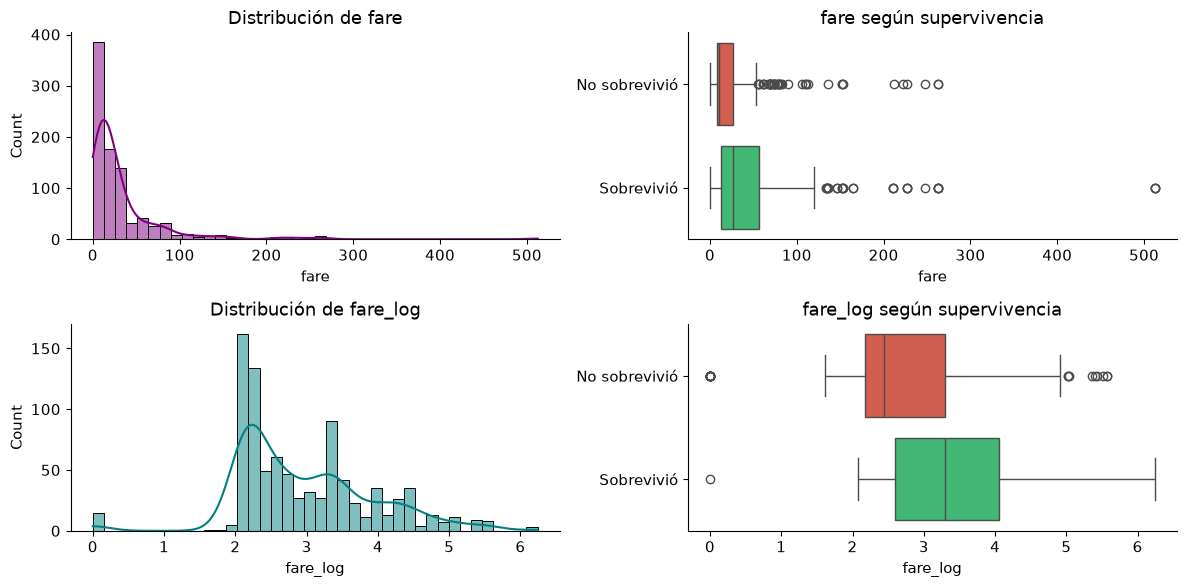

In [7]:
df_fe['fare_log'] = np.log1p(df_fe['fare'])

def resumen_forma(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)).sum()
    return pd.Series({'media': serie.mean(), 'mediana': serie.median(), 'desv. estándar': serie.std(),
                      'asimetría': serie.skew(), 'curtosis': serie.kurt(), 'outliers IQR': n_out})

efecto_fare = pd.DataFrame({'fare (original)': resumen_forma(df_fe['fare']),
                            'fare_log (transformada)': resumen_forma(df_fe['fare_log'])}).round(2)
print(efecto_fare)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for fila, col, color in [(0, 'fare', 'purple'), (1, 'fare_log', 'teal')]:
    sns.histplot(df_fe[col], bins=40, kde=True, color=color, ax=axes[fila, 0])
    axes[fila, 0].set_title(f'Distribución de {col}')
    sns.boxplot(data=df_fe, x=col, y='survived_label', hue='survived_label', palette=PALETTE,
                legend=False, ax=axes[fila, 1])
    axes[fila, 1].set_title(f'{col} según supervivencia'); axes[fila, 1].set_ylabel('')
plt.tight_layout()
plt.show()

registrar('IV', 'fare', 'Transformación log1p -> fare_log', 'H1: asimetría extrema y outliers reales',
          f'Asimetría {efecto_fare.loc["asimetría", "fare (original)"]} -> {efecto_fare.loc["asimetría", "fare_log (transformada)"]}; '
          f'outliers IQR {int(efecto_fare.loc["outliers IQR", "fare (original)"])} -> {int(efecto_fare.loc["outliers IQR", "fare_log (transformada)"])}')

**Efecto:** la transformación reduce la asimetría de **4,79 a 0,39** y la curtosis de **33,4 a 0,98**, y los outliers según el criterio IQR bajan de **116 a 31**, sin eliminar ningún registro. La media y la mediana quedan próximas (2,96 y 2,74), señal de una distribución más simétrica. Los boxplots muestran que la separación entre sobrevivientes y no sobrevivientes se aprecia mejor en la escala logarítmica, y la correlación lineal con `survived` aumenta de **0,26** (`fare`) a **0,33** (`fare_log`): la transformación no solo mejora la forma, sino que hace más visible la relación con el objetivo. Los 15 pasajeros con `fare = 0` quedan aislados en 0 en la nueva escala; se mantienen identificados con `fare_cero_flag` (H8).

### 2. Estandarización de `age` y `fare_log` → `age_z`, `fare_log_z` (H1, H2)
* **Operación:** *z-score* con `StandardScaler`: $z = (x - \bar{x}) / s$.
* **Propósito:** llevar las variables continuas a una escala común (media 0, desviación 1). `age` se mide en años (0,42–80) y `fare_log` en log-libras (0–6,2); sin estandarizar, los modelos basados en distancias o con regularización darían más peso a la variable de mayor rango. Se estandariza `fare_log` y no `fare`, porque el *z-score* no corrige la asimetría (H1) y se aplica una vez resuelta.

          media antes  desv. antes  rango antes  media después  desv. después  asimetría antes  asimetría después
age            29.112       13.297       79.580            0.0            1.0            0.534              0.534
fare_log        2.962        0.969        6.241           -0.0            1.0            0.395              0.395


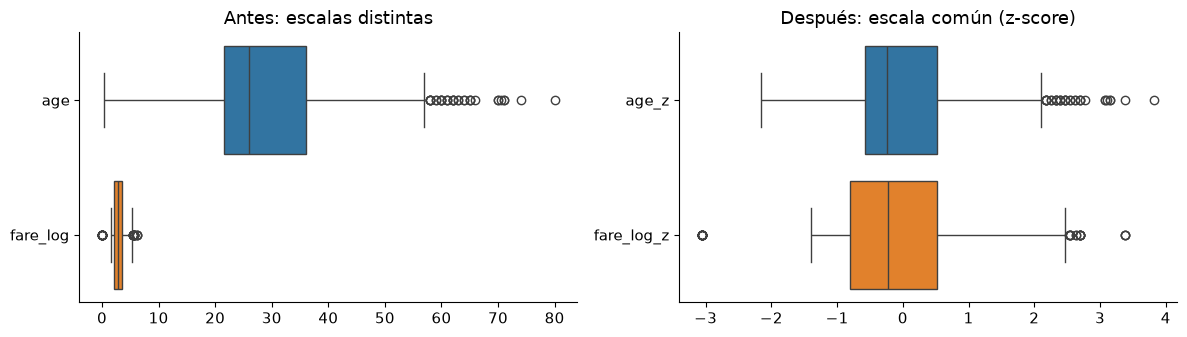

In [8]:
escalador = StandardScaler()
df_fe[['age_z', 'fare_log_z']] = escalador.fit_transform(df_fe[['age', 'fare_log']])

efecto_escala = pd.DataFrame({
    'media antes': df_fe[['age', 'fare_log']].mean().values,
    'desv. antes': df_fe[['age', 'fare_log']].std(ddof=0).values,
    'rango antes': (df_fe[['age', 'fare_log']].max() - df_fe[['age', 'fare_log']].min()).values,
    'media después': df_fe[['age_z', 'fare_log_z']].mean().values,
    'desv. después': df_fe[['age_z', 'fare_log_z']].std(ddof=0).values,
    'asimetría antes': df_fe[['age', 'fare_log']].skew().values,
    'asimetría después': df_fe[['age_z', 'fare_log_z']].skew().values,
}, index=['age', 'fare_log']).round(3)
print(efecto_escala)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
sns.boxplot(data=df_fe[['age', 'fare_log']], orient='h', ax=axes[0]); axes[0].set_title('Antes: escalas distintas')
sns.boxplot(data=df_fe[['age_z', 'fare_log_z']], orient='h', ax=axes[1]); axes[1].set_title('Después: escala común (z-score)')
plt.tight_layout()
plt.show()

for var in ['age', 'fare_log']:
    registrar('IV', var, f'Estandarización z-score -> {var}_z', 'H1/H2: escalas distintas entre variables continuas',
              f'Media {efecto_escala.loc[var, "media antes"]} -> 0; desv. {efecto_escala.loc[var, "desv. antes"]} -> 1; forma sin cambios')

**Efecto:** ambas variables quedan con **media 0 y desviación estándar 1**, y sus rangos pasan de 79,6 años y 6,2 log-libras a una escala comparable (unidades de desviación estándar). La asimetría **no cambia** (0,534 y 0,395), lo que confirma que el *z-score* solo modifica la ubicación y la escala, y no la forma: por eso la asimetría de `fare` se corrigió antes con `log1p`.

### 3. Codificación de variables categóricas (H3, H4)
* **`sex` → `sex_male`** (1 = hombre, 0 = mujer): codificación binaria de una variable nominal de dos categorías.
* **`embarked` → `emb_C`, `emb_Q`, `emb_S`**: codificación *one-hot* de una variable nominal sin orden natural. Se conservan las tres columnas en esta fase exploratoria; para un modelo lineal se omitirá una (categoría de referencia) para evitar colinealidad perfecta.
* **`pclass`**: se **mantiene como ordinal** (1, 2, 3) porque la supervivencia decrece de forma monótona con la clase (H4) y el orden tiene sentido socioeconómico.
* **`age_group` → `age_group_ord`** y **`fare_bin` → `fare_bin_ord`**: códigos ordinales (0, 1, 2…) que conservan el orden de los tramos.

In [9]:
df_fe['sex_male'] = (df_fe['sex'] == 'male').astype(int)
dummies_emb = pd.get_dummies(df_fe['embarked'], prefix='emb', dtype=int)
df_fe = pd.concat([df_fe, dummies_emb], axis=1)
df_fe['age_group_ord'] = df_fe['age_group'].cat.codes
df_fe['fare_bin_ord'] = df_fe['fare_bin'].cat.codes

# Verificación de la codificación: correspondencia 1 a 1 con la variable original
print(pd.crosstab(df_fe['sex'], df_fe['sex_male']), '\n')
print(df_fe.groupby('embarked')[['emb_C', 'emb_Q', 'emb_S']].max(), '\n')
print('Suma de dummies por fila = 1 en todas las filas:', (dummies_emb.sum(axis=1) == 1).all())
print(pd.crosstab(df_fe['age_group'], df_fe['age_group_ord']).to_string(), '\n')
print('Supervivencia (%) según fare_bin_ord:',
      df_fe.groupby('fare_bin_ord')['survived'].mean().mul(100).round(1).to_dict())

registrar('IV', 'sex', 'Codificación binaria -> sex_male', 'H3: variable nominal de 2 categorías y más asociada al objetivo',
          'Texto -> 0/1 (577 hombres = 1, 314 mujeres = 0)')
registrar('IV', 'embarked', 'Codificación one-hot -> emb_C, emb_Q, emb_S', 'Variable nominal sin orden natural',
          '1 columna de texto -> 3 columnas 0/1 (una activa por fila)')
registrar('IV', 'pclass', 'Se mantiene ordinal (1-3)', 'H4: gradiente monótono de supervivencia por clase', 'Sin cambios')
registrar('IV', 'age_group, fare_bin', 'Codificación ordinal -> age_group_ord, fare_bin_ord',
          'Tramos con orden natural', 'Categorías de texto -> enteros que preservan el orden')

sex_male    0    1
sex               
female    314    0
male        0  577 

          emb_C  emb_Q  emb_S
embarked                     
C             1      0      0
Q             0      1      0
S             0      0      1 

Suma de dummies por fila = 1 en todas las filas: True
age_group_ord   0   1    2    3   4
age_group                          
0-5 años       44   0    0    0   0
6-18 años       0  95    0    0   0
19-35 años      0   0  514    0   0
36-60 años      0   0    0  216   0
61+ años        0   0    0    0  22 

Supervivencia (%) según fare_bin_ord: {0: 19.7, 1: 30.4, 2: 45.5, 3: 58.1}


**Efecto:** las verificaciones muestran una correspondencia uno a uno entre cada variable original y su versión codificada (577 hombres = 1; cada pasajero tiene exactamente una columna `emb_*` activa; cada tramo de edad corresponde a un único código). La tasa de supervivencia crece de forma monótona con `fare_bin_ord` (19,7% → 30,4% → 45,5% → 58,1%), lo que respalda tratar los tramos como ordinales. Con estas codificaciones, todas las variables quedan en formato numérico, requisito para los métodos de selección de la Sección VI y para una etapa de modelamiento.

### 4. Recodificación de `family_size` en tramos → `family_cat` (H5)
* **Operación:** `family_size` se agrupa en tres categorías: **solo** (0 familiares), **pequena** (1 a 3) y **grande** (4 o más).
* **Propósito:** la relación entre el tamaño familiar y la supervivencia no es lineal ni monótona (H5): sube desde los pasajeros solos hasta los grupos de 3 y luego cae. Una variable numérica lineal no captura ese patrón; los tramos sí, y además agrupan los tamaños grandes con pocos casos (tasas inestables).

              n  tasa
family_cat           
solo        537  30.4
pequena     292  57.9
grande       62  16.1

Tamaños originales incluidos en cada tramo:
            min  max
family_cat          
solo          0    0
pequena       1    3
grande        4   10


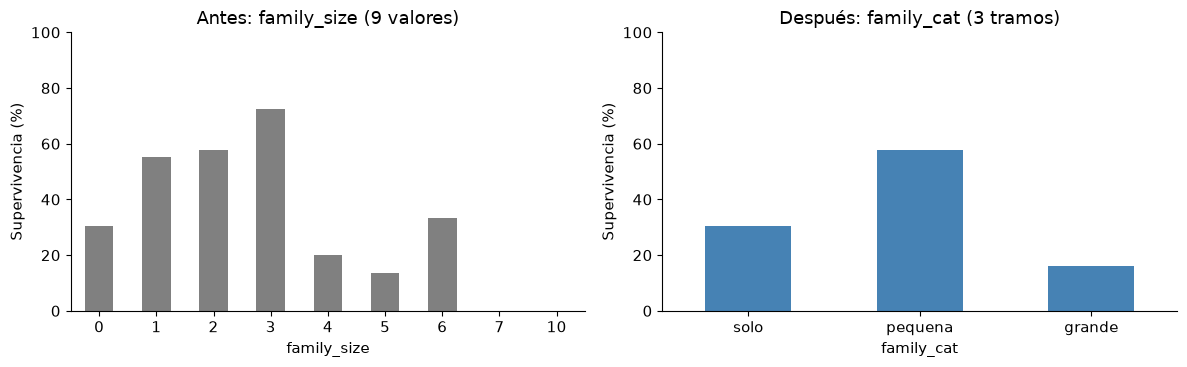

In [10]:
df_fe['family_cat'] = pd.cut(df_fe['family_size'], bins=[-1, 0, 3, 10],
                             labels=['solo', 'pequena', 'grande'])

efecto_familia = (df_fe.groupby('family_cat', observed=True)['survived']
                        .agg(n='count', tasa=lambda s: s.mean() * 100).round(1))
print(efecto_familia)
print('\nTamaños originales incluidos en cada tramo:')
print(df_fe.groupby('family_cat', observed=True)['family_size'].agg(['min', 'max']))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
df_fe.groupby('family_size')['survived'].mean().mul(100).plot(kind='bar', color='grey', ax=axes[0])
axes[0].set_title('Antes: family_size (9 valores)'); axes[0].set_ylabel('Supervivencia (%)')
efecto_familia['tasa'].plot(kind='bar', color='steelblue', ax=axes[1])
axes[1].set_title('Después: family_cat (3 tramos)'); axes[1].set_ylabel('Supervivencia (%)')
for ax in axes: ax.set_ylim(0, 100); ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

registrar('IV', 'family_size', 'Recodificación en tramos -> family_cat (solo / pequena / grande)',
          'H5: relación no lineal y tamaños grandes con pocos casos',
          '9 valores -> 3 categorías: ' + ', '.join(f'{k} {v}%' for k, v in efecto_familia['tasa'].items()))

**Efecto:** los 9 valores de `family_size` se resumen en 3 tramos con comportamientos claramente distintos: **solo 30,4%** (537 pasajeros), **pequena 57,9%** (292) y **grande 16,1%** (62). La recodificación conserva la forma de U invertida observada en el EDA y agrupa los tamaños con muy pocos casos (por ejemplo, 6 pasajeros con tamaño 7 y 7 con tamaño 10), cuyas tasas individuales eran inestables. En la Sección VI se verifica que esta versión recodificada tiene una asociación mucho mayor con la supervivencia que la variable numérica original.

### 5. Síntesis de las transformaciones

In [11]:
pd.DataFrame(log_decisiones).query("seccion == 'IV'")[['variable', 'accion', 'motivo', 'efecto']]

,variable,accion,motivo,efecto
1,fare,Transformación log1p -> fare_log,H1: asimetría extrema y outliers reales,Asimetría 4.79 -> 0.39; outliers IQR 116 -> 31
2,age,Estandarización z-score -> age_z,H1/H2: escalas distintas entre variables conti...,Media 29.112 -> 0; desv. 13.297 -> 1; forma si...
3,fare_log,Estandarización z-score -> fare_log_z,H1/H2: escalas distintas entre variables conti...,Media 2.962 -> 0; desv. 0.969 -> 1; forma sin ...
4,sex,Codificación binaria -> sex_male,H3: variable nominal de 2 categorías y más aso...,"Texto -> 0/1 (577 hombres = 1, 314 mujeres = 0)"
5,embarked,"Codificación one-hot -> emb_C, emb_Q, emb_S",Variable nominal sin orden natural,1 columna de texto -> 3 columnas 0/1 (una acti...
6,pclass,Se mantiene ordinal (1-3),H4: gradiente monótono de supervivencia por clase,Sin cambios
7,"age_group, fare_bin","Codificación ordinal -> age_group_ord, fare_bi...",Tramos con orden natural,Categorías de texto -> enteros que preservan e...
8,family_size,Recodificación en tramos -> family_cat (solo /...,H5: relación no lineal y tamaños grandes con p...,"9 valores -> 3 categorías: solo 30.4%, pequena..."


<a id='V'></a>
## V. Variables derivadas o creadas

Se crean cinco variables nuevas combinando o derivando información existente. Para cada una se identifican las variables de origen, la regla de construcción, la utilidad analítica esperada y la evidencia de su comportamiento frente a la supervivencia.

### 1. Interacción sexo × clase → `sexo_clase` (H4)
* **Origen:** `sex`, `pclass`.
* **Regla:** concatenación de ambas en 6 categorías: `mujer_1`, `mujer_2`, `mujer_3`, `hombre_1`, `hombre_2`, `hombre_3`.
* **Utilidad esperada:** el efecto de la clase no es igual para hombres y mujeres (H4). Un modelo lineal con `sex` y `pclass` por separado supone efectos aditivos y no captura que, por ejemplo, las mujeres de 3ª clase sobreviven mucho menos que las de 1ª y 2ª. La interacción explícita representa ese patrón y es fácilmente interpretable.

              n  tasa
sexo_clase           
mujer_1      94  96.8
mujer_2      76  92.1
mujer_3     144  50.0
hombre_1    122  36.9
hombre_2    108  15.7
hombre_3    347  13.5


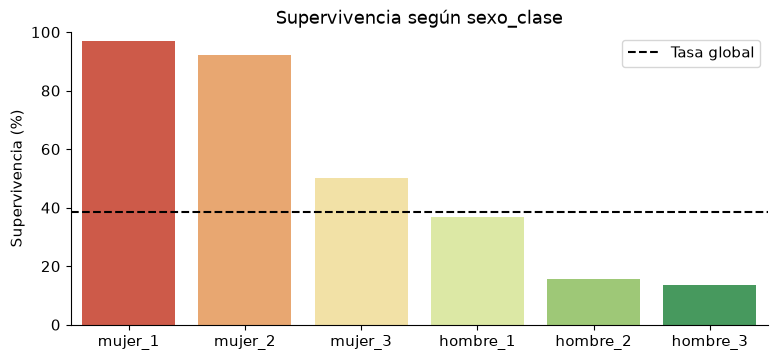

In [12]:
df_fe['sexo_clase'] = df_fe['sex'].map({'female': 'mujer', 'male': 'hombre'}) + '_' + df_fe['pclass'].astype(str)

tasa_sc = (df_fe.groupby('sexo_clase')['survived']
                .agg(n='count', tasa=lambda s: s.mean() * 100).round(1)
                .sort_values('tasa', ascending=False))
print(tasa_sc)

plt.figure(figsize=(9, 3.8))
sns.barplot(x=tasa_sc.index, y=tasa_sc['tasa'], hue=tasa_sc.index, palette='RdYlGn', legend=False)
plt.axhline(df_fe['survived'].mean() * 100, ls='--', c='k', label='Tasa global')
plt.title('Supervivencia según sexo_clase'); plt.ylabel('Supervivencia (%)'); plt.xlabel(''); plt.legend()
plt.ylim(0, 100)
plt.show()

registrar('V', 'sexo_clase', 'Nueva variable: sex + pclass (6 categorías)', 'H4: interacción sexo × clase',
          f'Rango de supervivencia {tasa_sc["tasa"].min()}% a {tasa_sc["tasa"].max()}%')

**Lectura:** la supervivencia va de **96,8%** (mujeres de 1ª clase) a **13,5%** (hombres de 3ª clase). La interacción es evidente: entre las mujeres, pasar de 1ª a 3ª clase reduce la supervivencia en 46,8 puntos (96,8% → 50,0%), mientras que entre los hombres la diferencia es de 23,4 puntos (36,9% → 13,5%) y ocurre sobre todo entre 1ª y 2ª clase. El efecto de la clase depende del sexo, algo que `sex` y `pclass` por separado no representan en un modelo aditivo.

### 2. Indicador de niñez → `es_nino` (H2)
* **Origen:** `age`.
* **Regla:** `es_nino = 1` si `age` ≤ 12 años; 0 en caso contrario. El umbral de 12 años se elige por el cambio de tendencia observado en el EDA (0–5 años: 70,5%; 6–18 años: 41,1%) y porque delimita la niñez previa a la adolescencia.
* **Utilidad esperada:** la edad tiene una correlación lineal casi nula con la supervivencia (−0,06), pero su efecto se concentra en los niños («mujeres y niños primero»). Un indicador binario captura ese efecto de forma directa, especialmente en los hombres, para quienes ser niño debería marcar una diferencia importante.

In [13]:
df_fe['es_nino'] = (df_fe['age'] <= 12).astype(int)

print('Pasajeros con es_nino = 1:', df_fe['es_nino'].sum())
print('¿Algún niño proviene de una edad imputada?',
      bool(((df_fe['es_nino'] == 1) & df_raw['age'].isnull()).any()))
tasa_nino = (df_fe.groupby(['sex', 'es_nino'])['survived']
                  .agg(n='count', tasa=lambda s: s.mean() * 100).round(1))
print(tasa_nino)

registrar('V', 'es_nino', 'Nueva variable: 1 si age <= 12', 'H2: efecto de la edad concentrado en los niños',
          f'{df_fe["es_nino"].sum()} niños; supervivencia niños {df_fe.loc[df_fe.es_nino == 1, "survived"].mean() * 100:.1f}% '
          f'vs resto {df_fe.loc[df_fe.es_nino == 0, "survived"].mean() * 100:.1f}%')

Pasajeros con es_nino = 1: 69
¿Algún niño proviene de una edad imputada? False
                  n  tasa
sex    es_nino           
female 0        282  75.9
       1         32  59.4
male   0        540  16.3
       1         37  56.8


**Lectura:** 69 pasajeros tienen 12 años o menos, con una supervivencia de **58,0%** frente a **36,7%** del resto. El efecto se concentra en los hombres: los niños sobreviven en un **56,8%** frente a solo **16,3%** de los hombres adultos, lo que refleja el protocolo «mujeres y niños primero». En las mujeres ocurre lo contrario (59,4% en niñas vs 75,9% en adultas), probablemente porque muchas niñas viajaban en 3ª clase. Ningún niño proviene de una edad imputada, ya que las medianas imputadas van de 21,5 a 40 años: los niños sin edad registrada quedan clasificados como no niños (limitación documentada en la Sección IX).

### 3. Tarifa por persona → `tarifa_pp_log` (H1)
* **Origen:** `fare`, `family_size`.
* **Regla:** `tarifa_pp_log = log(1 + fare / (family_size + 1))`. En el Titanic la tarifa corresponde al boleto, que puede cubrir a todo un grupo familiar; dividir por el número de personas del grupo aproxima el gasto individual. Se aplica `log1p` por la misma razón que en `fare` (H1).
* **Utilidad esperada:** separar el nivel socioeconómico individual del tamaño del grupo: una familia numerosa de 3ª clase puede pagar una tarifa total alta sin ser de nivel alto.

In [14]:
df_fe['tarifa_pp_log'] = np.log1p(df_fe['fare'] / (df_fe['family_size'] + 1))

comparacion_tarifa = pd.DataFrame({
    'asimetría': [df_fe['fare_log'].skew(), df_fe['tarifa_pp_log'].skew()],
    'r con survived': [df_fe['fare_log'].corr(df_fe['survived']), df_fe['tarifa_pp_log'].corr(df_fe['survived'])],
    'r con pclass': [df_fe['fare_log'].corr(df_fe['pclass']), df_fe['tarifa_pp_log'].corr(df_fe['pclass'])],
    'r con family_size': [df_fe['fare_log'].corr(df_fe['family_size']), df_fe['tarifa_pp_log'].corr(df_fe['family_size'])],
}, index=['fare_log', 'tarifa_pp_log']).round(3)
print(comparacion_tarifa)
print(f"\nCorrelación fare_log vs tarifa_pp_log: {df_fe['fare_log'].corr(df_fe['tarifa_pp_log']):.3f}")

registrar('V', 'tarifa_pp_log', 'Nueva variable: log1p(fare / (family_size + 1))',
          'H1: separar gasto individual del tamaño del grupo',
          f'r con family_size {comparacion_tarifa.loc["fare_log", "r con family_size"]} -> {comparacion_tarifa.loc["tarifa_pp_log", "r con family_size"]}')

               asimetría  r con survived  r con pclass  r con family_size
fare_log           0.395           0.330        -0.661              0.384
tarifa_pp_log      0.690           0.299        -0.722             -0.171

Correlación fare_log vs tarifa_pp_log: 0.823


**Lectura:** al dividir por el tamaño del grupo, la correlación con `family_size` pasa de **0,38 a −0,17**, es decir, la nueva variable ya no está inflada por el número de familiares. A cambio, su relación con `pclass` se vuelve más fuerte (−0,72 frente a −0,66) y su correlación con la supervivencia es levemente menor (0,30 frente a 0,33). Como `fare_log` y `tarifa_pp_log` están muy correlacionadas entre sí (0,82), en la Sección VI se decide cuál de las dos conservar.

### 4. Indicadores de faltantes → `deck_conocido`, `edad_imputada` (H7)
* **Origen:** columnas originales `deck` y `age` de `df_raw` (antes de la imputación y de la exclusión de `deck`). Las filas están en el mismo orden (verificado en la Sección III).
* **Regla:** `deck_conocido = 1` si la cubierta está registrada; `edad_imputada = 1` si la edad original faltaba y fue imputada.
* **Utilidad esperada:** en el EDA se observó que los faltantes **no son aleatorios** (H7). El hecho de que un dato falte puede reflejar diferencias en el registro de los pasajeros (por ejemplo, la cubierta se registraba sobre todo en Primera Clase). Estos indicadores rescatan esa información: `deck_conocido` recupera parte del valor de `deck` sin imputar un 77% de datos, y `edad_imputada` permite al modelo distinguir las edades reales de las imputadas.

In [15]:
df_fe['deck_conocido'] = df_raw['deck'].notnull().astype(int).values
df_fe['edad_imputada'] = df_raw['age'].isnull().astype(int).values

for flag in ['deck_conocido', 'edad_imputada']:
    t = df_fe.groupby(flag)['survived'].agg(n='count', tasa=lambda s: s.mean() * 100).round(1)
    print(f'{flag}:\n{t}\n')
print('% de deck_conocido por clase:', df_fe.groupby('pclass')['deck_conocido'].mean().mul(100).round(1).to_dict())
print('% de edad_imputada por clase:', df_fe.groupby('pclass')['edad_imputada'].mean().mul(100).round(1).to_dict())

registrar('V', 'deck_conocido', 'Nueva variable: 1 si deck está registrado (df_raw)',
          'H7: faltante informativo; rescata información de deck sin imputar',
          f'{df_fe["deck_conocido"].sum()} con cubierta; supervivencia '
          f'{df_fe.loc[df_fe.deck_conocido == 1, "survived"].mean() * 100:.1f}% vs {df_fe.loc[df_fe.deck_conocido == 0, "survived"].mean() * 100:.1f}%')
registrar('V', 'edad_imputada', 'Nueva variable: 1 si age fue imputada (df_raw)',
          'H7: faltantes de age no aleatorios',
          f'{df_fe["edad_imputada"].sum()} imputadas; supervivencia '
          f'{df_fe.loc[df_fe.edad_imputada == 1, "survived"].mean() * 100:.1f}% vs {df_fe.loc[df_fe.edad_imputada == 0, "survived"].mean() * 100:.1f}%')

deck_conocido:
                 n  tasa
deck_conocido           
0              688  29.9
1              203  67.0

edad_imputada:
                 n  tasa
edad_imputada           
0              714  40.6
1              177  29.4

% de deck_conocido por clase: {1: 81.0, 2: 8.7, 3: 2.4}
% de edad_imputada por clase: {1: 13.9, 2: 6.0, 3: 27.7}


**Lectura:** los pasajeros con cubierta registrada sobreviven en un **67,0%** frente a **29,9%** de los que no la tienen, y aquellos con edad imputada sobreviven menos (**29,4%** vs **40,6%**). Ambas diferencias confirman que los faltantes son informativos (H7). Sin embargo, `deck_conocido` está muy ligado a la clase (81,0% de registro en 1ª clase frente a 2,4% en 3ª), por lo que parte de su asociación con la supervivencia puede reflejar la clase y no la ubicación en el barco; su redundancia con `pclass` se evalúa en la Sección VI.

### 5. Síntesis de las variables derivadas

In [16]:
pd.DataFrame(log_decisiones).query("seccion == 'V'")[['variable', 'accion', 'motivo', 'efecto']]

,variable,accion,motivo,efecto
9,sexo_clase,Nueva variable: sex + pclass (6 categorías),H4: interacción sexo × clase,Rango de supervivencia 13.5% a 96.8%
10,es_nino,Nueva variable: 1 si age <= 12,H2: efecto de la edad concentrado en los niños,69 niños; supervivencia niños 58.0% vs resto 3...
11,tarifa_pp_log,Nueva variable: log1p(fare / (family_size + 1)),H1: separar gasto individual del tamaño del grupo,r con family_size 0.384 -> -0.171
12,deck_conocido,Nueva variable: 1 si deck está registrado (df_...,H7: faltante informativo; rescata información ...,203 con cubierta; supervivencia 67.0% vs 29.9%
13,edad_imputada,Nueva variable: 1 si age fue imputada (df_raw),H7: faltantes de age no aleatorios,177 imputadas; supervivencia 29.4% vs 40.6%


<a id='VI'></a>
## VI. Selección preliminar de características

### 1. Criterios de selección
Cada variable candidata se evalúa con cinco criterios explícitos:

| Código | Criterio | Cómo se mide |
|---|---|---|
| **C1** | Relevancia analítica / predictiva | Correlación punto-biserial con `survived` (variables numéricas y binarias), V de Cramér (categóricas) e información mutua (todas) |
| **C2** | Redundancia | Correlación de Spearman entre predictoras (umbral \|ρ\| ≥ 0,7) y factor de inflación de la varianza (VIF > 5) |
| **C3** | Interpretabilidad | Si la variable tiene una lectura clara en el contexto del problema |
| **C4** | Consistencia y calidad | Nulos, estabilidad (categorías con pocos casos) y dependencia de imputaciones |
| **C5** | Sentido operativo / fuga de información | Si la variable estaría disponible antes de conocer el resultado y no repite el objetivo |

Las decisiones posibles son: **Priorizar** (núcleo del modelo), **Conservar** (aporta información complementaria), **Revisar** (evaluar en la etapa de modelamiento) y **Descartar**.

### 2. Relevancia (C1): asociación con la supervivencia

In [17]:
# ── Variables numéricas y binarias: correlación punto-biserial ───────────
num_cand = ['sex_male', 'pclass', 'age_z', 'fare_log_z', 'tarifa_pp_log', 'family_size', 'sibsp', 'parch',
            'es_nino', 'deck_conocido', 'edad_imputada', 'fare_cero_flag', 'emb_C', 'emb_Q', 'emb_S',
            'age_group_ord', 'fare_bin_ord', 'lat', 'lon']
filas = []
for v in num_cand:
    r, p = stats.pointbiserialr(df_fe['survived'], df_fe[v])
    filas.append({'variable': v, 'r_pb': r, 'p_valor': p})
relev_num = pd.DataFrame(filas).set_index('variable')

# ── Variables categóricas: chi-cuadrado y V de Cramér ────────────────────
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2, p, _, _ = stats.chi2_contingency(tabla, correction=False)
    n = tabla.values.sum()
    return np.sqrt(chi2 / (n * (min(tabla.shape) - 1))), p

cat_cand = ['sex', 'pclass', 'sexo_clase', 'embarked', 'family_cat', 'viaja_solo', 'age_group', 'fare_bin',
            'es_nino', 'deck_conocido', 'edad_imputada', 'fare_cero_flag', 'puerto', 'pais']
relev_cat = pd.DataFrame([dict(zip(['variable', 'V_cramer', 'p_valor_chi2'], (v, *cramers_v(df_fe[v], df_fe['survived']))))
                          for v in cat_cand]).set_index('variable')

# ── Información mutua (captura relaciones no lineales) ───────────────────
X_mi = pd.DataFrame({
    'sex_male': df_fe['sex_male'], 'pclass': df_fe['pclass'], 'age_z': df_fe['age_z'],
    'fare_log_z': df_fe['fare_log_z'], 'tarifa_pp_log': df_fe['tarifa_pp_log'],
    'family_size': df_fe['family_size'], 'sibsp': df_fe['sibsp'], 'parch': df_fe['parch'],
    'family_cat': df_fe['family_cat'].cat.codes, 'sexo_clase': df_fe['sexo_clase'].astype('category').cat.codes,
    'embarked': df_fe['embarked'].astype('category').cat.codes, 'es_nino': df_fe['es_nino'],
    'deck_conocido': df_fe['deck_conocido'], 'edad_imputada': df_fe['edad_imputada'],
    'fare_cero_flag': df_fe['fare_cero_flag'], 'age_group_ord': df_fe['age_group_ord'],
    'fare_bin_ord': df_fe['fare_bin_ord'], 'viaja_solo': (df_fe['viaja_solo'] == 'Solo').astype(int),
})
discretas = [c not in ('age_z', 'fare_log_z', 'tarifa_pp_log') for c in X_mi.columns]
mi = pd.Series(mutual_info_classif(X_mi, df_fe['survived'], discrete_features=discretas,
                                   random_state=SEMILLA), index=X_mi.columns, name='info_mutua')

print('=== Correlación punto-biserial con survived ===')
print(relev_num.assign(abs_r=relev_num['r_pb'].abs()).sort_values('abs_r', ascending=False)
      .drop(columns='abs_r').round(4).to_string())
print('\n=== V de Cramér con survived ===')
print(relev_cat.sort_values('V_cramer', ascending=False).round(4).to_string())
print('\n=== Información mutua con survived ===')
print(mi.sort_values(ascending=False).round(4).to_string())

=== Correlación punto-biserial con survived ===
                  r_pb  p_valor
variable                       
sex_male       -0.5434   0.0000
pclass         -0.3385   0.0000
fare_log_z      0.3299   0.0000
deck_conocido   0.3196   0.0000
fare_bin_ord    0.2994   0.0000
tarifa_pp_log   0.2988   0.0000
emb_C           0.1682   0.0000
emb_S          -0.1497   0.0000
lat            -0.1379   0.0000
es_nino         0.1167   0.0005
age_group_ord  -0.1085   0.0012
edad_imputada  -0.0922   0.0059
fare_cero_flag -0.0853   0.0108
parch           0.0816   0.0148
age_z          -0.0596   0.0755
sibsp          -0.0353   0.2922
family_size     0.0166   0.6199
lon            -0.0106   0.7515
emb_Q           0.0037   0.9134

=== V de Cramér con survived ===
                V_cramer  p_valor_chi2
variable                              
sexo_clase        0.6274        0.0000
sex               0.5434        0.0000
pclass            0.3398        0.0000
deck_conocido     0.3196        0.0000
fare_bin    

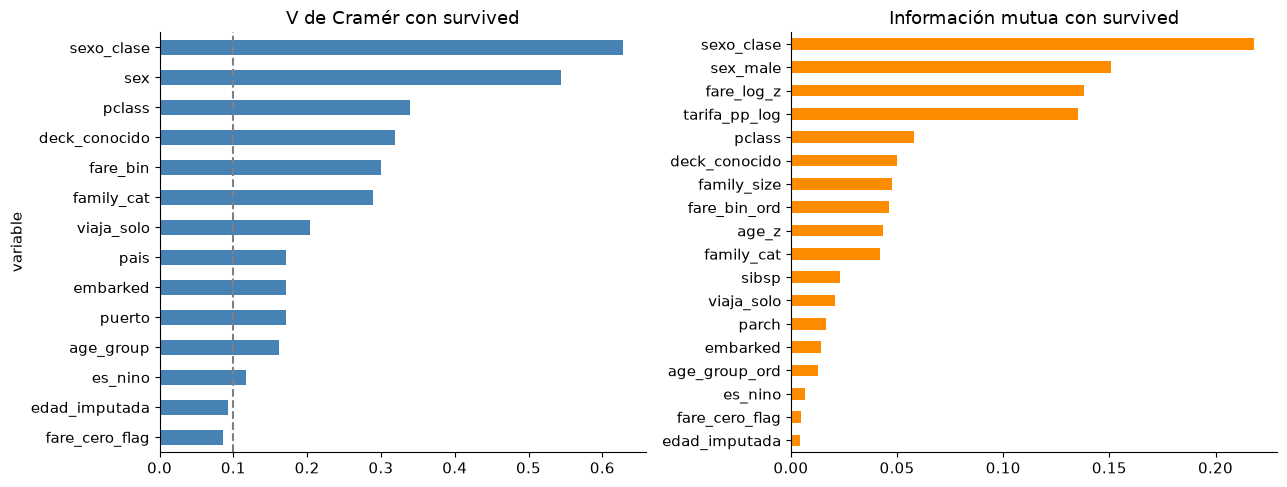

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
relev_cat['V_cramer'].sort_values().plot(kind='barh', color='steelblue', ax=axes[0])
axes[0].set_title('V de Cramér con survived'); axes[0].axvline(0.1, ls='--', c='grey')
mi.sort_values().plot(kind='barh', color='darkorange', ax=axes[1])
axes[1].set_title('Información mutua con survived')
plt.tight_layout()
plt.show()

**Lectura de la relevancia (C1):**
* **Asociación fuerte:** `sexo_clase` es la variable más asociada a la supervivencia (V de Cramér **0,63**; información mutua **0,218**), por encima de `sex` (0,54) y `pclass` (0,34) por separado, lo que confirma el valor de la interacción creada en la Sección V.
* **Asociación moderada:** `fare_log_z` (r = 0,33; IM 0,138), `deck_conocido` (0,32), `fare_bin` (0,30), `tarifa_pp_log` (0,30) y `family_cat` (V = 0,29).
* **Efecto de la recodificación:** `family_size` como variable numérica no tiene asociación lineal significativa (r = 0,02; p = 0,62), pero su versión en tramos `family_cat` alcanza V = 0,29. Lo mismo ocurre con la edad: `age_z` tiene una correlación lineal débil y no significativa (r = −0,06; p = 0,08), pero una información mutua mayor (0,044), lo que indica una relación no lineal que `es_nino` y `family_cat` ayudan a capturar.
* **Asociación débil:** `edad_imputada` (V = 0,09), `fare_cero_flag` (0,09), `es_nino` (0,12, aunque con un efecto fuerte en hombres), `sibsp`, `parch`, `emb_Q` y `lon` (no significativas).
* `embarked`, `puerto` y `pais` tienen exactamente la misma V de Cramér (0,171): contienen la misma información.

### 3. Redundancia (C2): correlación entre predictoras y multicolinealidad

Pares con |ρ de Spearman| ≥ 0,7:
 variable_1    variable_2    rho
 fare_log_z  fare_bin_ord  0.968
      age_z age_group_ord  0.891
      emb_C           lat -0.866
family_size         sibsp  0.849
family_size         parch  0.801
     pclass tarifa_pp_log -0.768


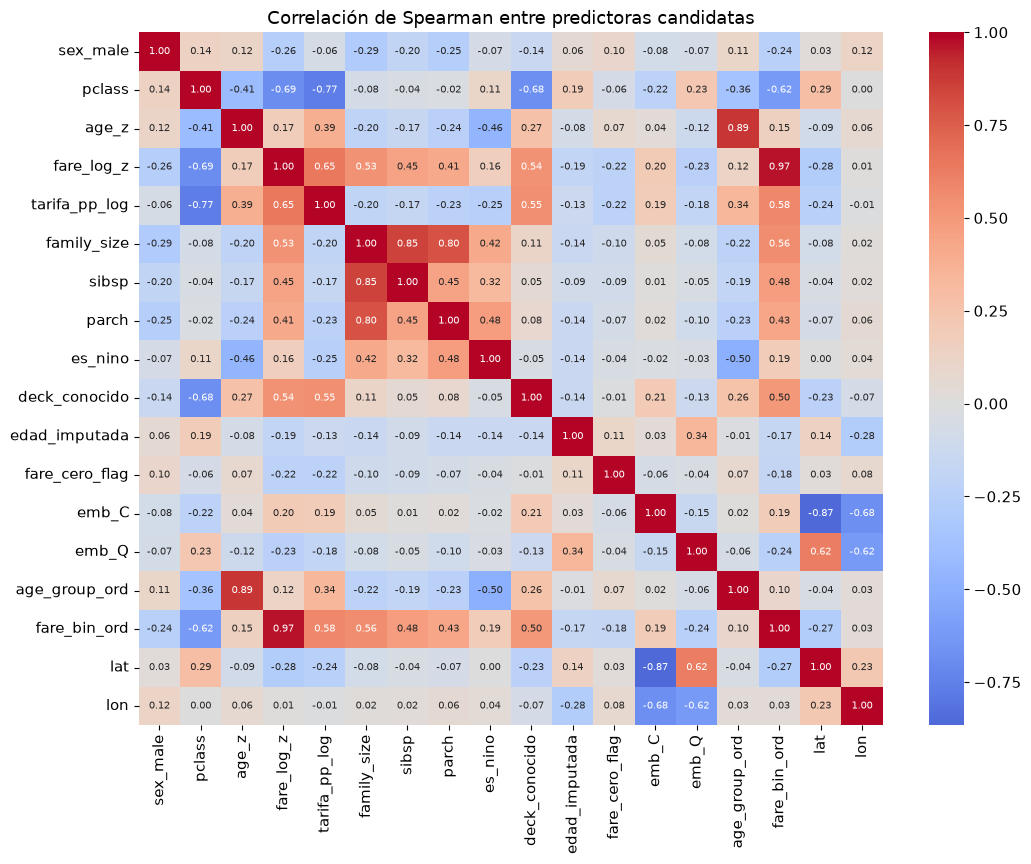

In [19]:
redund_cols = ['sex_male', 'pclass', 'age_z', 'fare_log_z', 'tarifa_pp_log', 'family_size', 'sibsp', 'parch',
               'es_nino', 'deck_conocido', 'edad_imputada', 'fare_cero_flag', 'emb_C', 'emb_Q',
               'age_group_ord', 'fare_bin_ord', 'lat', 'lon']
rho = df_fe[redund_cols].corr(method='spearman')

pares = (rho.where(np.triu(np.ones(rho.shape, dtype=bool), k=1)).stack()
            .rename('rho').reset_index().rename(columns={'level_0': 'variable_1', 'level_1': 'variable_2'}))
pares_altos = pares[pares['rho'].abs() >= 0.7].sort_values('rho', key=abs, ascending=False)
print('Pares con |ρ de Spearman| ≥ 0,7:')
print(pares_altos.round(3).to_string(index=False))

plt.figure(figsize=(12, 9))
sns.heatmap(rho, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size': 7})
plt.title('Correlación de Spearman entre predictoras candidatas')
plt.show()

In [20]:
def calcular_vif(X):
    """VIF_j = 1 / (1 - R²_j), regresando cada variable sobre las demás.
    Si R² = 1 (colinealidad perfecta) el VIF es infinito."""
    vif = {}
    for c in X.columns:
        r2 = LinearRegression().fit(X.drop(columns=c), X[c]).score(X.drop(columns=c), X[c])
        vif[c] = np.inf if r2 > 1 - 1e-9 else 1 / (1 - r2)
    return pd.Series(vif, name='VIF')

# Conjunto amplio (con redundancias) vs conjunto sin las variables redundantes
vif_amplio = calcular_vif(df_fe[['sex_male', 'pclass', 'age_z', 'fare_log_z', 'tarifa_pp_log', 'family_size',
                                 'sibsp', 'parch', 'es_nino', 'deck_conocido', 'edad_imputada', 'emb_C', 'emb_Q']])
vif_reducido = calcular_vif(df_fe[['sex_male', 'pclass', 'age_z', 'fare_log_z', 'es_nino',
                                   'deck_conocido', 'edad_imputada', 'emb_C', 'emb_Q']])
print(pd.concat([vif_amplio.rename('VIF conjunto amplio'), vif_reducido.rename('VIF conjunto reducido')], axis=1)
        .round(2).sort_values('VIF conjunto amplio', ascending=False).to_string())

               VIF conjunto amplio  VIF conjunto reducido
family_size                    inf                    NaN
sibsp                          inf                    NaN
parch                          inf                    NaN
fare_log_z                   31.73                   2.06
tarifa_pp_log                25.42                    NaN
pclass                        3.47                   3.12
deck_conocido                 2.16                   2.15
age_z                         1.79                   1.77
es_nino                       1.73                   1.53
edad_imputada                 1.25                   1.22
emb_Q                         1.23                   1.21
sex_male                      1.18                   1.12
emb_C                         1.15                   1.12


**Lectura de la redundancia (C2):**
* **Colinealidad perfecta:** `family_size`, `sibsp` y `parch` tienen VIF infinito porque `family_size = sibsp + parch`. No pueden usarse juntas.
* **Pares redundantes (|ρ| ≥ 0,7):** `fare_log_z`–`fare_bin_ord` (0,97), `age_z`–`age_group_ord` (0,89), `emb_C`–`lat` (−0,87), `family_size`–`sibsp`/`parch` (0,85 / 0,80) y `pclass`–`tarifa_pp_log` (−0,77). Las versiones en tramos (`fare_bin`, `age_group`) repiten la información de las variables continuas, y las coordenadas del puerto repiten `embarked`.
* **Multicolinealidad entre tarifas:** `fare_log_z` y `tarifa_pp_log` juntas alcanzan VIF de 31,7 y 25,4. Al conservar solo una de ellas y eliminar las variables familiares redundantes, el VIF máximo baja a **3,1** (`pclass`), por debajo del umbral de 5.

### 4. Tabla de decisión por variable
La tabla consolida, para **cada variable** del dataset de trabajo, la decisión adoptada, los criterios que la sustentan y su justificación.

In [21]:
decisiones = [
    # (variable, decisión, criterios, justificación)
    
    ('sex_male', 'Priorizar', 'C1, C3', 'Mayor asociación individual (r = -0,54; V = 0,54; IM 0,151); sin redundancia (VIF 1,1); lectura directa (H3)'),
    ('pclass', 'Priorizar', 'C1, C3', 'Gradiente monótono de supervivencia (V = 0,34); ordinal interpretable; VIF 3,1 aceptable (H4)'),
    ('fare_log_z', 'Priorizar', 'C1, C2', 'Asociación moderada (r = 0,33; IM 0,138) con forma corregida y escala común; aporta nivel económico más allá de la clase (VIF 2,1)'),
    ('sexo_clase', 'Conservar', 'C1, C3', 'Mayor asociación del conjunto (V = 0,63; IM 0,218); representa la interacción sexo × clase (H4). Colineal por construcción con sex_male y pclass: usar como interacción'),
    ('family_cat', 'Conservar', 'C1, C2', 'Captura la relación no lineal del tamaño familiar (V = 0,29 vs r = 0,02 de family_size); reemplaza a family_size, sibsp, parch y viaja_solo (H5)'),
    ('age_z', 'Conservar', 'C1, C3', 'Relación lineal débil (r = -0,06) pero IM 0,044 indica relación no lineal; necesaria junto a es_nino para representar la edad'),
    ('es_nino', 'Conservar', 'C1, C3', 'Efecto fuerte en hombres (16,3% -> 56,8%); representa el protocolo «mujeres y niños primero» (H2)'),
    ('deck_conocido', 'Conservar', 'C1, C4', 'Asociación moderada (V = 0,32) sin imputar deck; ligada a 1ª clase pero con VIF 2,2 (H7)'),
    ('tarifa_pp_log', 'Revisar', 'C2', 'Relevante (r = 0,30) pero redundante con fare_log_z (r = 0,82; VIF 25 juntas); evaluar como alternativa a fare_log_z'),
    ('embarked (emb_C, emb_Q, emb_S)', 'Revisar', 'C1, C4', 'Asociación moderada (V = 0,17) atribuible en parte a la composición por clase del puerto (H8); evaluar su aporte en el modelo'),
    ('edad_imputada', 'Revisar', 'C1, C4', 'Asociación débil (V = 0,09; IM 0,004); podría ayudar a corregir el sesgo de la imputación de age (H7)'),
    ('fare_cero_flag', 'Revisar', 'C1, C4', 'Asociación débil (V = 0,09) y solo 15 casos: categoría inestable (H8)'),
    ('sex', 'Descartar', 'C2', 'Reemplazada por su codificación sex_male'),
    ('age', 'Descartar', 'C2', 'Reemplazada por su versión estandarizada age_z'),
    ('fare', 'Descartar', 'C2, C4', 'Asimetría 4,79; reemplazada por fare_log_z (H1)'),
    ('fare_log', 'Descartar', 'C2', 'Paso intermedio; reemplazada por fare_log_z'),
    ('sibsp', 'Descartar', 'C1, C2', 'No significativa (r = -0,04) y colineal perfecta con family_size (VIF infinito)'),
    ('parch', 'Descartar', 'C1, C2', 'Asociación débil (r = 0,08) y colineal perfecta con family_size (VIF infinito)'),
    ('family_size', 'Descartar', 'C1, C2', 'Sin asociación lineal (r = 0,02; p = 0,62); reemplazada por family_cat'),
    ('viaja_solo', 'Descartar', 'C2', 'Información contenida en family_cat (categoría solo)'),
    ('age_group / age_group_ord', 'Descartar', 'C2', 'Redundante con age_z (ρ = 0,89); el efecto de la niñez lo captura es_nino'),
    ('fare_bin / fare_bin_ord', 'Descartar', 'C2', 'Redundante con fare_log_z (ρ = 0,97); la versión continua conserva más información'),
    ('puerto', 'Descartar', 'C2', 'Misma información que embarked (V idéntica = 0,171)'),
    ('pais', 'Descartar', 'C2', 'Misma información que embarked (V idéntica = 0,171)'),
    ('lat', 'Descartar', 'C2, C3', 'Redundante con emb_C (ρ = -0,87); la ubicación geográfica del puerto no tiene lectura causal'),
    ('lon', 'Descartar', 'C1, C2', 'No significativa (r = -0,01) y dependiente de embarked'),
    ('deck', 'Descartar', 'C4', '77,2% de faltantes; su información se conserva en deck_conocido (H7)'),
    ('survived_label', 'Descartar', 'C5', 'Repite la variable objetivo: fuga de información'),

]
seleccion = pd.DataFrame(decisiones, columns=['variable', 'decision', 'criterios', 'justificacion'])
orden = {'Priorizar': 0, 'Conservar': 1, 'Revisar': 2, 'Descartar': 3}
seleccion = seleccion.sort_values('decision', key=lambda s: s.map(orden)).reset_index(drop=True)

print(seleccion['decision'].value_counts().reindex(list(orden)).to_string())
for _, fila in seleccion.iterrows():
    registrar('VI', fila['variable'], fila['decision'], fila['criterios'], fila['justificacion'])
with pd.option_context('display.max_colwidth', 120):
    display(seleccion)

decision
Priorizar     3
Conservar     5
Revisar       4
Descartar    16


,variable,decision,criterios,justificacion
0,sex_male,Priorizar,"C1, C3","Mayor asociación individual (r = -0,54; V = 0,54; IM 0,151); sin redundancia (VIF 1,1); lectura directa (H3)"
1,pclass,Priorizar,"C1, C3","Gradiente monótono de supervivencia (V = 0,34); ordinal interpretable; VIF 3,1 aceptable (H4)"
2,fare_log_z,Priorizar,"C1, C2","Asociación moderada (r = 0,33; IM 0,138) con forma corregida y escala común; aporta nivel económico más allá de la c..."
3,sexo_clase,Conservar,"C1, C3","Mayor asociación del conjunto (V = 0,63; IM 0,218); representa la interacción sexo × clase (H4). Colineal por constr..."
4,family_cat,Conservar,"C1, C2","Captura la relación no lineal del tamaño familiar (V = 0,29 vs r = 0,02 de family_size); reemplaza a family_size, si..."
5,age_z,Conservar,"C1, C3","Relación lineal débil (r = -0,06) pero IM 0,044 indica relación no lineal; necesaria junto a es_nino para representa..."
6,es_nino,Conservar,"C1, C3","Efecto fuerte en hombres (16,3% -> 56,8%); representa el protocolo «mujeres y niños primero» (H2)"
7,deck_conocido,Conservar,"C1, C4","Asociación moderada (V = 0,32) sin imputar deck; ligada a 1ª clase pero con VIF 2,2 (H7)"
8,tarifa_pp_log,Revisar,C2,"Relevante (r = 0,30) pero redundante con fare_log_z (r = 0,82; VIF 25 juntas); evaluar como alternativa a fare_log_z"
9,"embarked (emb_C, emb_Q, emb_S)",Revisar,"C1, C4","Asociación moderada (V = 0,17) atribuible en parte a la composición por clase del puerto (H8); evaluar su aporte en ..."


**Resultado de la selección:** de las 28 variables evaluadas, **3 se priorizan** (`sex_male`, `pclass`, `fare_log_z`), **5 se conservan** (`sexo_clase`, `family_cat`, `age_z`, `es_nino`, `deck_conocido`), **4 quedan en revisión** para la etapa de modelamiento (`tarifa_pp_log`, `embarked`, `edad_imputada`, `fare_cero_flag`) y **16 se descartan**, principalmente por redundancia (C2), por haber sido reemplazadas por su versión transformada o por riesgo de fuga de información (C5). Las variables priorizadas y conservadas forman el conjunto de características del dataset final (Sección VIII).

<a id='VII'></a>
## VII. Documentación y trazabilidad del pipeline

### 1. Registro consolidado de decisiones
Todas las decisiones de las secciones III a VI quedaron registradas con `registrar()` en el momento en que se ejecutaron. La tabla muestra, para cada paso, la acción realizada, el motivo (hallazgo o criterio) y el efecto observado en los datos.

In [22]:
log_df = pd.DataFrame(log_decisiones)
print(f'Decisiones registradas: {len(log_df)}')
print(log_df.groupby('seccion')['paso'].count().rename('n_decisiones').to_string())
with pd.option_context('display.max_colwidth', 90, 'display.max_rows', 100):
    display(log_df)

Decisiones registradas: 42
seccion
III     1
IV      8
V       5
VI     28


,paso,seccion,variable,accion,motivo,efecto
0,1,III,dataset completo,Reaplicar limpieza e integración de Fases 2-3 (preparar_base),Punto de partida trazable e independiente del notebook anterior,"(891, 15) con 869 nulos -> (891, 18) con 0 nulos"
1,2,IV,fare,Transformación log1p -> fare_log,H1: asimetría extrema y outliers reales,Asimetría 4.79 -> 0.39; outliers IQR 116 -> 31
2,3,IV,age,Estandarización z-score -> age_z,H1/H2: escalas distintas entre variables continuas,Media 29.112 -> 0; desv. 13.297 -> 1; forma sin cambios
3,4,IV,fare_log,Estandarización z-score -> fare_log_z,H1/H2: escalas distintas entre variables continuas,Media 2.962 -> 0; desv. 0.969 -> 1; forma sin cambios
4,5,IV,sex,Codificación binaria -> sex_male,H3: variable nominal de 2 categorías y más asociada al objetivo,"Texto -> 0/1 (577 hombres = 1, 314 mujeres = 0)"
5,6,IV,embarked,"Codificación one-hot -> emb_C, emb_Q, emb_S",Variable nominal sin orden natural,1 columna de texto -> 3 columnas 0/1 (una activa por fila)
6,7,IV,pclass,Se mantiene ordinal (1-3),H4: gradiente monótono de supervivencia por clase,Sin cambios
7,8,IV,"age_group, fare_bin","Codificación ordinal -> age_group_ord, fare_bin_ord",Tramos con orden natural,Categorías de texto -> enteros que preservan el orden
8,9,IV,family_size,Recodificación en tramos -> family_cat (solo / pequena / grande),H5: relación no lineal y tamaños grandes con pocos casos,"9 valores -> 3 categorías: solo 30.4%, pequena 57.9%, grande 16.1%"
9,10,V,sexo_clase,Nueva variable: sex + pclass (6 categorías),H4: interacción sexo × clase,Rango de supervivencia 13.5% a 96.8%


### 2. Pipeline reproducible con `scikit-learn`
Las transformaciones y variables derivadas seleccionadas se encapsulan en un único objeto `Pipeline`, que puede ajustarse con un conjunto de entrenamiento y aplicarse a datos nuevos sin repetir código ni filtrar información del conjunto de prueba:

1. `derivadas`: `FunctionTransformer` que crea `sex_male`, `sexo_clase`, `es_nino` y `family_cat` a partir de las variables de `df_base`.
2. `preprocesamiento`: `ColumnTransformer` que aplica `log1p` + *z-score* a `fare`, *z-score* a `age`, *one-hot* a las categóricas y deja pasar las variables binarias y ordinales.

Las variables de entrada son las de `df_base` más `deck_conocido`, que depende de la columna original `deck` de `df_raw`. Solo se incluyen las variables **priorizadas y conservadas** en la Sección VI.

In [23]:
def crear_derivadas(X):
    """Variables derivadas de la Sección V que se calculan fila a fila (sin parámetros ajustables)."""
    X = X.copy()
    X['sex_male'] = (X['sex'] == 'male').astype(int)
    X['sexo_clase'] = X['sex'].map({'female': 'mujer', 'male': 'hombre'}) + '_' + X['pclass'].astype(str)
    X['es_nino'] = (X['age'] <= 12).astype(int)
    X['family_cat'] = pd.cut(X['family_size'], bins=[-1, 0, 3, 10], labels=['solo', 'pequena', 'grande']).astype(str)
    return X

VARS_LOG_Z = ['fare']
VARS_Z = ['age']
VARS_OHE = ['family_cat', 'sexo_clase']
VARS_PASO = ['sex_male', 'pclass', 'es_nino', 'deck_conocido']

pipeline_fe = Pipeline([
    ('derivadas', FunctionTransformer(crear_derivadas)),
    ('preprocesamiento', ColumnTransformer([
        ('log_z', Pipeline([('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
                            ('z', StandardScaler())]), VARS_LOG_Z),
        ('z', StandardScaler(), VARS_Z),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), VARS_OHE),
        ('paso', 'passthrough', VARS_PASO),
    ], verbose_feature_names_out=False)),
])
pipeline_fe.set_output(transform='pandas')

# Entrada del pipeline: df_base + indicador de cubierta registrada
df_entrada = df_base.assign(deck_conocido=df_fe['deck_conocido'])
X_pipe = pipeline_fe.fit_transform(df_entrada)

# Verificación: el pipeline reproduce exactamente los pasos manuales de las secciones IV y V
print('fare (pipeline) = fare_log_z (manual):', np.allclose(X_pipe['fare'], df_fe['fare_log_z']))
print('age  (pipeline) = age_z (manual):     ', np.allclose(X_pipe['age'], df_fe['age_z']))
print('es_nino idéntico:                     ', (X_pipe['es_nino'] == df_fe['es_nino']).all())
print(f'\nSalida del pipeline: {X_pipe.shape[0]} filas × {X_pipe.shape[1]} columnas')
print(list(X_pipe.columns))

fare (pipeline) = fare_log_z (manual): True
age  (pipeline) = age_z (manual):      True
es_nino idéntico:                      True

Salida del pipeline: 891 filas × 15 columnas
['fare', 'age', 'family_cat_grande', 'family_cat_pequena', 'family_cat_solo', 'sexo_clase_hombre_1', 'sexo_clase_hombre_2', 'sexo_clase_hombre_3', 'sexo_clase_mujer_1', 'sexo_clase_mujer_2', 'sexo_clase_mujer_3', 'sex_male', 'pclass', 'es_nino', 'deck_conocido']


In [24]:
# Uso previsto en la etapa de modelamiento: ajustar solo con entrenamiento
X_train, X_test, y_train, y_test = train_test_split(
    df_entrada, df_entrada['survived'], test_size=0.2, stratify=df_entrada['survived'], random_state=SEMILLA)

pipeline_fe.fit(X_train)
Xt_train, Xt_test = pipeline_fe.transform(X_train), pipeline_fe.transform(X_test)
escaler_fare = pipeline_fe.named_steps['preprocesamiento'].named_transformers_['log_z'].named_steps['z']
print(f'Entrenamiento: {Xt_train.shape} | Prueba: {Xt_test.shape}')
print(f'Media de fare_log usada para escalar (solo entrenamiento): {escaler_fare.mean_[0]:.4f}')
print(f'Proporción de sobrevivientes -> entrenamiento {y_train.mean():.3f} | prueba {y_test.mean():.3f}')
print(f'Media de fare en prueba tras escalar (no es exactamente 0): {Xt_test["fare"].mean():.4f}')

registrar('VII', 'pipeline', 'Encapsular transformaciones en Pipeline de scikit-learn',
          'Reproducibilidad y prevención de fuga de información',
          f'Reproduce los pasos manuales; salida {X_pipe.shape[1]} columnas; ajustable solo con entrenamiento')

Entrenamiento: (712, 15) | Prueba: (179, 15)
Media de fare_log usada para escalar (solo entrenamiento): 2.9508
Proporción de sobrevivientes -> entrenamiento 0.383 | prueba 0.385
Media de fare en prueba tras escalar (no es exactamente 0): 0.0582


**Lectura:** el pipeline reproduce exactamente los resultados de los pasos manuales (`fare` = `fare_log_z`, `age` = `age_z`, `es_nino` idéntico), por lo que la documentación de las secciones IV y V corresponde a lo que efectivamente se aplica. Al ajustarlo solo con el conjunto de entrenamiento (712 filas, partición estratificada que mantiene 38,3% y 38,5% de sobrevivientes), la media usada para escalar `fare_log` es 2,951 (frente a 2,962 con todo el dataset), y la media del conjunto de prueba escalado no es exactamente 0 (0,058): el conjunto de prueba no influye en los parámetros, lo que evita la fuga de información en la etapa de modelamiento.

### 3. Correspondencia entre acciones y efectos

In [25]:
correspondencia = pd.DataFrame([
    
    ('log1p en fare', 'IV.1', 'Asimetría de fare', efecto_fare.loc['asimetría', 'fare (original)'], efecto_fare.loc['asimetría', 'fare_log (transformada)']),
    ('log1p en fare', 'IV.1', 'Outliers IQR en fare', int(efecto_fare.loc['outliers IQR', 'fare (original)']), int(efecto_fare.loc['outliers IQR', 'fare_log (transformada)'])),
    ('log1p en fare', 'IV.1', 'r con survived', round(df_fe['fare'].corr(df_fe['survived']), 2), round(df_fe['fare_log'].corr(df_fe['survived']), 2)),
    ('z-score age', 'IV.2', 'Media / desv. de age', f"{efecto_escala.loc['age', 'media antes']} / {efecto_escala.loc['age', 'desv. antes']}", '0 / 1'),
    ('Codificación de categóricas', 'IV.3', 'Columnas no numéricas', int((~df_base.dtypes.apply(pd.api.types.is_numeric_dtype)).sum()), 0),
    ('Recodificación family_size', 'IV.4', 'Categorías / V de Cramér', f"{df_fe['family_size'].nunique()} valores / r = {df_fe['family_size'].corr(df_fe['survived']):.2f}", f"3 tramos / V = {relev_cat.loc['family_cat', 'V_cramer']:.2f}"),
    ('sexo_clase', 'V.1', 'Rango de supervivencia entre categorías (%)', f"{df_fe.groupby('sex')['survived'].mean().min() * 100:.1f}–{df_fe.groupby('sex')['survived'].mean().max() * 100:.1f} (sex)", f"{tasa_sc['tasa'].min()}–{tasa_sc['tasa'].max()}"),
    ('es_nino', 'V.2', 'Supervivencia de hombres (%)', f"{tasa_nino.loc[('male', 0), 'tasa']} (adultos)", f"{tasa_nino.loc[('male', 1), 'tasa']} (niños)"),
    ('deck_conocido', 'V.4', 'Supervivencia (%)', f"{df_fe.loc[df_fe.deck_conocido == 0, 'survived'].mean() * 100:.1f} (sin cubierta)", f"{df_fe.loc[df_fe.deck_conocido == 1, 'survived'].mean() * 100:.1f} (con cubierta)"),
    ('Selección de variables', 'VI', 'VIF máximo', 'inf (conjunto amplio)', round(vif_reducido.max(), 2)),
    ('Selección de variables', 'VI', 'Variables evaluadas / seleccionadas', len(seleccion), int(seleccion['decision'].isin(['Priorizar', 'Conservar']).sum())),

], columns=['acción', 'sección', 'indicador', 'antes', 'después'])
correspondencia

,acción,sección,indicador,antes,después
0,log1p en fare,IV.1,Asimetría de fare,4.79,0.39
1,log1p en fare,IV.1,Outliers IQR en fare,116,31
2,log1p en fare,IV.1,r con survived,0.26,0.33
3,z-score age,IV.2,Media / desv. de age,29.112 / 13.297,0 / 1
4,Codificación de categóricas,IV.3,Columnas no numéricas,8,0
5,Recodificación family_size,IV.4,Categorías / V de Cramér,9 valores / r = 0.02,3 tramos / V = 0.29
6,sexo_clase,V.1,Rango de supervivencia entre categorías (%),18.9–74.2 (sex),13.5–96.8
7,es_nino,V.2,Supervivencia de hombres (%),16.3 (adultos),56.8 (niños)
8,deck_conocido,V.4,Supervivencia (%),29.9 (sin cubierta),67.0 (con cubierta)
9,Selección de variables,VI,VIF máximo,inf (conjunto amplio),3.12


<a id='VIII'></a>
## VIII. Resultado final del dataset preparado

### 1. Dataset final para modelamiento (`df_modelo`)
El dataset final se obtiene aplicando el pipeline de la Sección VII (ajustado con el dataset completo, para fines exploratorios) y agregando la variable objetivo. Contiene solo las variables **priorizadas y conservadas** en la Sección VI; las variables en revisión permanecen disponibles en `df_fe` para evaluarlas en la etapa de modelamiento.

In [26]:
pipeline_fe.fit(df_entrada)
df_modelo = pipeline_fe.transform(df_entrada)
# Se usan los mismos nombres de las secciones IV-VI para las variables escaladas
df_modelo = df_modelo.rename(columns={'fare': 'fare_log_z', 'age': 'age_z'})
df_modelo['survived'] = df_base['survived'].values

print(f'df_modelo: {df_modelo.shape[0]} filas × {df_modelo.shape[1]} columnas '
      f'({df_modelo.shape[1] - 1} características + objetivo)')
print(f'Valores nulos: {df_modelo.isnull().sum().sum()}')
print(f'Tipos de datos: {df_modelo.dtypes.value_counts().to_dict()}')
print(f'Columnas constantes: {[c for c in df_modelo.columns if df_modelo[c].nunique() == 1]}')
df_modelo.head()

df_modelo: 891 filas × 16 columnas (15 características + objetivo)
Valores nulos: 0
Tipos de datos: {dtype('float64'): 11, dtype('int64'): 5}
Columnas constantes: []


,fare_log_z,age_z,family_cat_grande,family_cat_pequena,family_cat_solo,sexo_clase_hombre_1,sexo_clase_hombre_2,sexo_clase_hombre_3,sexo_clase_mujer_1,sexo_clase_mujer_2,sexo_clase_mujer_3,sex_male,pclass,es_nino,deck_conocido,survived
0,-0.879741,-0.534891,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,3,0,0,0
1,1.361220,0.668392,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,0,1,1
2,-0.798540,-0.234070,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,3,0,0,1
3,1.062038,0.442776,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,0,1,1
4,-0.784179,0.442776,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1,3,0,0,0


In [27]:
df_modelo.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
fare_log_z,891.0,-0.000,1.001,-3.059,-0.800,-0.232,0.520,3.385
age_z,891.0,0.000,1.001,-2.158,-0.572,-0.234,0.518,3.827
family_cat_grande,891.0,0.070,0.255,0.000,0.000,0.000,0.000,1.000
family_cat_pequena,891.0,0.328,0.470,0.000,0.000,0.000,1.000,1.000
family_cat_solo,891.0,0.603,0.490,0.000,0.000,1.000,1.000,1.000
sexo_clase_hombre_1,891.0,0.137,0.344,0.000,0.000,0.000,0.000,1.000
sexo_clase_hombre_2,891.0,0.121,0.327,0.000,0.000,0.000,0.000,1.000
sexo_clase_hombre_3,891.0,0.389,0.488,0.000,0.000,0.000,1.000,1.000
sexo_clase_mujer_1,891.0,0.105,0.307,0.000,0.000,0.000,0.000,1.000
sexo_clase_mujer_2,891.0,0.085,0.279,0.000,0.000,0.000,0.000,1.000


### 2. Comparación entre el estado inicial y el final

In [28]:
def perfil(df, nombre):
    num = df.select_dtypes('number')
    return pd.Series({
        'filas': df.shape[0], 'columnas': df.shape[1],
        'valores nulos': int(df.isnull().sum().sum()),
        'columnas no numéricas': int((~df.dtypes.apply(pd.api.types.is_numeric_dtype)).sum()),
        'asimetría máx. (continuas)': round(num.loc[:, num.nunique() > 20].skew().abs().max(), 2),
        'rango máx. entre columnas': round((num.max() - num.min()).max(), 1),
    }, name=nombre)

comparacion_final = pd.concat([perfil(df_raw, 'df_raw (inicio)'), perfil(df_base, 'df_base (tras F2-F3)'),
                               perfil(df_modelo, 'df_modelo (final)')], axis=1)
comparacion_final

,df_raw (inicio),df_base (tras F2-F3),df_modelo (final)
filas,891.00,891.00,891.00
columnas,15.00,18.00,16.00
valores nulos,869.00,0.00,0.00
columnas no numéricas,7.00,8.00,0.00
asimetría máx. (continuas),4.79,4.79,0.53
rango máx. entre columnas,512.30,512.30,6.40


In [29]:
# Evolución de la forma y la escala de las variables continuas en cada etapa
resumen_continuas = pd.DataFrame([
    (etapa, var, d[var].skew(), d[var].std())
    for etapa, d, pares in [('df_raw', df_raw, ['age', 'fare']),
                            ('df_base', df_base, ['age', 'fare']),
                            ('df_modelo', df_modelo, ['age_z', 'fare_log_z'])]
    for var in pares
], columns=['dataset', 'variable', 'asimetría', 'desviación estándar'])
resumen_continuas.round(3)

,dataset,variable,asimetría,desviación estándar
0,df_raw,age,0.389,14.526
1,df_raw,fare,4.787,49.693
2,df_base,age,0.534,13.304
3,df_base,fare,4.787,49.693
4,df_modelo,age_z,0.534,1.001
5,df_modelo,fare_log_z,0.395,1.001


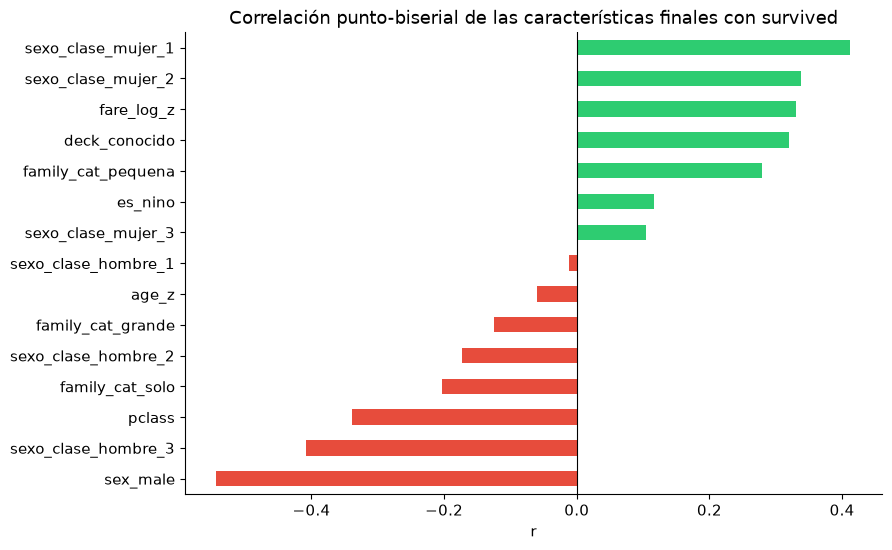

VIF de las características finales (family_cat sin su categoría de referencia "solo";


sexo_clase se excluye porque es una función exacta de sex_male y pclass):
pclass                3.36
fare_log_z            2.78
deck_conocido         2.15
age_z                 1.74
family_cat_grande     1.65
es_nino               1.63
family_cat_pequena    1.48
sex_male              1.15


In [30]:
# Asociación de cada característica final con la supervivencia
r_final = (df_modelo.drop(columns='survived')
           .apply(lambda c: stats.pointbiserialr(df_modelo['survived'], c)[0])
           .sort_values())
plt.figure(figsize=(9, 6))
r_final.plot(kind='barh', color=np.where(r_final > 0, '#2ecc71', '#e74c3c'))
plt.axvline(0, c='k', lw=0.8)
plt.title('Correlación punto-biserial de las características finales con survived')
plt.xlabel('r')
plt.show()

vif_final = calcular_vif(df_modelo[['fare_log_z', 'age_z', 'sex_male', 'pclass', 'es_nino', 'deck_conocido', 'family_cat_pequena', 'family_cat_grande']])
print('VIF de las características finales (family_cat sin su categoría de referencia "solo";')
print('sexo_clase se excluye porque es una función exacta de sex_male y pclass):')
print(vif_final.round(2).sort_values(ascending=False).to_string())

In [31]:
# Exportación del dataset preparado (insumo para la etapa de modelamiento)
import os
os.makedirs('data/processed', exist_ok=True)
df_modelo.to_csv('data/processed/titanic_fase4_modelo.csv', index=False)
print('Archivo exportado: data/processed/titanic_fase4_modelo.csv', df_modelo.shape)

Archivo exportado: data/processed/titanic_fase4_modelo.csv (891, 16)


**Lectura del resultado final:**
* **Dataset preparado:** `df_modelo` tiene 891 filas y **16 columnas** (15 características + `survived`), sin valores nulos, sin columnas constantes y con todas sus variables en formato numérico.
* **Mejoras respecto del estado inicial:** se pasa de 869 valores nulos a 0, de 7 columnas no numéricas a 0, de una asimetría máxima de 4,79 (`fare`) a 0,53 (`age_z`) y de un rango máximo de 512,3 unidades a 6,4, lo que deja todas las variables en escalas comparables. La tabla de variables continuas lo confirma: la asimetría de la tarifa baja de 4,787 (`fare`) a 0,395 (`fare_log_z`), la de la edad sube levemente con la imputación (0,389 → 0,534) y ambas variables quedan con desviación estándar cercana a 1.
* **Sin multicolinealidad severa:** el VIF máximo del conjunto final es **3,36** (`pclass`), por debajo del umbral de 5, frente a valores infinitos en el conjunto amplio de la Sección VI.
* **Relación con la supervivencia:** el gráfico confirma que las características finales conservan las asociaciones identificadas en el EDA: el sexo masculino y la categoría `hombre_3` se asocian negativamente con la supervivencia, mientras que `mujer_1`, `mujer_2`, la tarifa y la cubierta registrada lo hacen positivamente.
* **Preparación para modelamiento:** el dataset puede usarse directamente en modelos basados en árboles. Para un modelo lineal se debe omitir una categoría de referencia en `family_cat` y usar `sexo_clase` como interacción (o en reemplazo de `sex_male` y `pclass`), además de ajustar el pipeline solo con entrenamiento. El archivo exportado (`data/processed/titanic_fase4_modelo.csv`) queda como insumo para la etapa siguiente.

<a id='IX'></a>
## IX. Supuestos, limitaciones y cierre del notebook

Esta sección cierra la Fase 4. Primero se resume el pipeline construido; luego se declaran los supuestos sobre los que operan las decisiones, las limitaciones que condicionan la interpretación de los resultados y la proyección del trabajo hacia la etapa de modelamiento.

### 1. Resumen del pipeline implementado

| N.° | Etapa | Acción realizada | Resultado |
|---|---|---|---|
| 1 | Carga (II) | Dataset Titanic desde `seaborn` y tabla de puertos desde el repositorio del proyecto | `df_raw`: 891 × 15, 869 valores nulos |
| 2 | Limpieza (III) | `preparar_base()` reaplica las decisiones de las Fases 2 y 3: elimina columnas redundantes, imputa `age` y `embarked`, integra la tabla de puertos y excluye `deck` | `df_base`: 891 × 18, 0 valores nulos |
| 3 | Transformación (IV) | `log1p` en `fare`, *z-score* en `age` y `fare_log`, codificación binaria, *one-hot* y ordinal, recodificación de `family_size` en tramos | Asimetría de `fare`: 4,79 → 0,39; outliers IQR: 116 → 31 |
| 4 | Variables derivadas (V) | `sexo_clase`, `es_nino`, `tarifa_pp_log`, `deck_conocido` y `edad_imputada` | 5 variables nuevas, cada una asociada a un hallazgo del EDA |
| 5 | Selección preliminar (VI) | Criterios C1–C5: punto-biserial, V de Cramér, información mutua, Spearman y VIF | 28 variables evaluadas: 3 priorizadas, 5 conservadas, 4 en revisión y 16 descartadas |
| 6 | Trazabilidad (VII) | Registro `log_decisiones` y `Pipeline` + `ColumnTransformer` ajustable solo con entrenamiento (partición estratificada 80/20) | 42 decisiones registradas; el pipeline reproduce exactamente los pasos manuales |
| 7 | Dataset final (VIII) | `df_modelo` con 15 características + `survived`, exportado a CSV | 891 × 16, sin nulos, 100% numérico, VIF máximo 3,36 |

### 2. Supuestos
Los supuestos son condiciones que se dan por ciertas para tomar una decisión, aunque los datos disponibles no permitan comprobarlas por completo. Si un supuesto no se cumple, la decisión que depende de él pierde validez; por eso se declaran explícitamente.

* **[S1] Los faltantes de `age` son MAR.** Se aplica en la imputación por la mediana de `pclass` × `sex` (III). Se sostiene porque los faltantes se concentran según una variable observada (27,7% en 3ª clase vs 6,0% en 2ª). Si no se cumpliera, la mediana podría introducir sesgo; un indicio de ello es que faltan más edades entre los no sobrevivientes (22,8% vs 15,2%). Por esta razón se creó `edad_imputada`, que queda en revisión para el modelamiento.
* **[S2] Los cortes elegidos representan cambios de comportamiento.** Se aplica en `family_cat` (0 / 1–3 / ≥ 4), `es_nino` (≤ 12 años), `age_group` y `fare_bin` (cuartiles). Los umbrales se definieron a partir de patrones del EDA (H2 y H5); como se eligieron observando los mismos datos que luego se usarán para modelar, podrían estar ajustados a la muestra, y otros cortes razonables entregarían resultados distintos.
* **[S3] La tarifa corresponde al grupo familiar declarado.** Se aplica en `tarifa_pp_log = log1p(fare / (family_size + 1))` (V), porque habitualmente un boleto cubría a varios integrantes de una familia. En la práctica, un boleto podía incluir amistades o personal de servicio no registrados como familia, y algunos familiares viajaban con boletos separados; sin la columna `ticket` no es verificable, por lo que la tarifa por persona es una aproximación.
* **[S4] Las 107 filas duplicadas corresponden a pasajeros distintos.** La versión de `seaborn` no incluye identificadores, por lo que dos personas con el mismo perfil producen filas idénticas. Si fueran errores de registro, algunos perfiles quedarían sobrerrepresentados y su peso en un modelo aumentaría artificialmente.
* **[S5] Las tarifas iguales a 0 son valores reales.** Pueden corresponder a invitados o personal y no a errores de ingreso; por ello se marcaron con `fare_cero_flag` (III). Si fueran errores, distorsionarían el extremo inferior de `fare_log`. `fare_cero_flag` queda en revisión y no se incluye en `df_modelo`.
* **[S6] `embarked` puede imputarse con la moda.** Se imputaron 2 registros con «S» (III); al afectar solo al 0,2% de los datos, su impacto en los resultados es despreciable.

### 3. Limitaciones
* **[L1] La selección de variables fue bivariada.** La correlación punto-biserial, la V de Cramér y la información mutua evaluaron cada variable por separado frente a `survived`. Este enfoque no detecta variables que solo aportan en combinación con otras, ni identifica por sí solo cuándo dos variables relevantes cuentan la misma historia (para eso se usaron Spearman y VIF). Además, la correlación punto-biserial solo capta relaciones lineales, y la información mutua de las variables continuas es una estimación basada en vecinos cercanos.
* **[L2] Confusión con la clase.** `pclass` está relacionada con casi todas las demás variables: `fare`, `tarifa_pp_log`, `deck_conocido` (81,0% de registro en 1ª clase vs 2,4% en 3ª), `edad_imputada` y `embarked`. Por ejemplo, la mayor supervivencia de Cherbourg (55,4%) se explica en parte por su proporción de pasajeros de 1ª clase. Parte de la asociación observada en estas variables puede ser un efecto indirecto de la clase y, al tratarse de un análisis observacional, las asociaciones no permiten afirmar relaciones causales.
* **[L3] Efectos de la imputación de `age`.** Se reemplazaron 177 edades (19,9%) por la mediana de su grupo, lo que reduce la variabilidad de la edad (desviación estándar de 14,53 a 13,30) y genera concentraciones artificiales en seis valores. Además, los niños sin edad registrada reciben una mediana adulta, por lo que `es_nino` subestima el número real de niños.
* **[L4] Tamaño de la muestra.** Con 891 registros, varios grupos tienen pocos casos (44 pasajeros de 0 a 5 años, 22 de 61 años o más, 62 en `family_cat = grande`, 69 niños de 12 años o menos), por lo que sus tasas de supervivencia son inestables. El conjunto de prueba de 179 registros entregaría estimaciones con alta variabilidad, y el dataset es solo una parte de las cerca de 2.200 personas que iban a bordo, lo que limita la generalización.
* **[L5] Colinealidad por construcción.** `sexo_clase` es una función exacta de `sex` y `pclass`; en un modelo lineal debe usarse en reemplazo de ellas o como término de interacción, omitiendo categorías de referencia.
* **[L6] Escalado exploratorio.** `df_modelo` se escaló con todo el dataset para fines descriptivos; en el modelamiento se debe usar el pipeline ajustado solo con entrenamiento (Sección VII.2).

### 4. Proyección hacia el modelamiento

#### 4.1 Modelos
La etapa de modelamiento debería avanzar de lo más simple a lo más complejo, de modo que cada mejora sea medible:
* **Línea base:** `DummyClassifier(strategy='most_frequent')`, que siempre predice «No sobrevivió» y alcanza un 61,6% de exactitud. Cualquier modelo útil debe superar con claridad ese valor.
* **Modelo base interpretable:** regresión logística con regularización L2, cuyos coeficientes (interpretados como *odds ratios*) permiten contrastar los resultados con el EDA.
* **Modelos de comparación:** árbol de decisión y *random forest*, capaces de capturar interacciones y relaciones no lineales.

#### 4.2 Validación
* Trabajar solo con el conjunto de entrenamiento y usar validación cruzada estratificada (`StratifiedKFold` con 5 pliegues, `shuffle=True`, `random_state=42`), manteniendo en cada pliegue la proporción de sobrevivientes.
* Incluir dentro del pipeline todo paso que aprenda de los datos (imputación, escalado, codificación e idealmente la selección de variables), para que cada pliegue se ajuste sin ver los datos con que se evalúa.
* Reportar varias métricas además de la exactitud: ROC-AUC, F1, precisión y *recall*.
* Usar el conjunto de prueba una sola vez, para confirmar el desempeño del modelo elegido.

#### 4.3 Variables en revisión

| Variable | Motivo de la revisión | Cómo resolverlo en el modelamiento |
|---|---|---|
| `tarifa_pp_log` | Correlación de 0,82 con `fare_log` (redundancia) y supuesto S3 no verificable | Comparar con validación cruzada un modelo con cada versión y conservar la de mejor desempeño |
| `embarked` | Asociación moderada (V = 0,17) confundida con la clase (L2) | Evaluar su aporte con y sin la variable, controlando por `pclass` |
| `edad_imputada` | Asociación débil (V = 0,09); posible indicador indirecto de la clase (S1, L2) | Medir su aporte con importancia por permutación |
| `fare_cero_flag` | Solo 15 casos, con 1 sobreviviente (S5) | Evaluar su aporte o documentar su exclusión definitiva |
| `deck_conocido` (conservada) | Posible «segundo indicador» de la clase (L2) | Comparar el desempeño con y sin la variable |
| `es_nino` vs `age_z` (conservadas) | Información parcialmente superpuesta; `es_nino` afectada por la imputación (L3) | Evaluar si `es_nino` aporta más allá de `age_z`, sobre todo en modelos lineales |
| Cortes de `family_cat` y `es_nino` | Supuesto S2 | Análisis de sensibilidad con umbrales alternativos |

### 5. Cierre
El pipeline transformó los datos originales en un dataset reducido, completo y trazable: de 15 columnas con 869 valores nulos y escalas muy distintas se llegó a 15 características numéricas, sin nulos y en escalas comparables, en las que cada transformación y variable creada queda respaldada por un hallazgo del EDA y registrada en `log_decisiones`.

Los resultados confirman que la interacción entre el sexo y la clase es el factor más asociado a la supervivencia, seguida por el sexo, la clase, la tarifa, la niñez y el tamaño del grupo familiar. Este conjunto reducido permite priorizar los factores con mayor peso explicativo y sirve de base para construir un modelo de clasificación de la supervivencia.

Como se indicó en los supuestos y limitaciones, las conclusiones son preliminares y asociativas. El siguiente paso es validar estas decisiones con modelos evaluados mediante validación cruzada, manteniendo todo el preprocesamiento dentro del pipeline para evitar fuga de información, y resolver las variables que quedaron en revisión.

<a id='X'></a>
## X. Bibliografía

Guyon, I., y Elisseeff, A. (2003). An introduction to variable and feature selection. *Journal of Machine Learning Research*, *3*, 1157–1182.

Kuhn, M., y Johnson, K. (2019). *Feature engineering and selection: A practical approach for predictive models*. CRC Press. https://doi.org/10.1201/9781315108230

Little, R. J. A., y Rubin, D. B. (2019). *Statistical analysis with missing data* (3.ª ed.). Wiley.

McKinney, W. (2010). Data structures for statistical computing in Python. En *Proceedings of the 9th Python in Science Conference* (pp. 56–61). https://doi.org/10.25080/Majora-92bf1922-00a

Paraíso, S. (2026). *Material del curso MCDI503 — Exploración Inteligente para la Ciencia de Datos* [Material de curso]. Universidad Andrés Bello, Online.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825–2830.

Tukey, J. W. (1977). *Exploratory data analysis*. Addison-Wesley.

Waskom, M. L. (2021). seaborn: Statistical data visualization. *Journal of Open Source Software*, *6*(60), 3021. https://doi.org/10.21105/joss.03021

Zheng, A., y Casari, A. (2018). *Feature engineering for machine learning: Principles and techniques for data scientists*. O'Reilly Media.